#  Comprehensive EDA — E-Commerce Customer Churn Dataset

**Dataset:** `ecommerce_customer_churn_dataset.csv`  
**Targets:**
-  `Churned` → Binary Classification (Churn Prediction)
-  `Lifetime_Value` → Regression (LTV Prediction)
-  `LTV_Segment` → Multiclass Classification (LTV Segmentation — engineered from Lifetime_Value)

**Structure follows Appendix B (Q1 → Q20)**

##  Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

---
## Section A — Dataset Overview + Types

### Q1 — Dataset Overview: What do we have?

In [2]:
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print('\n--- 5 Sample Rows ---')
display(df.sample(5, random_state=42))
print('\n--- All Column Names ---')
print(list(df.columns))

Rows: 50,000  |  Columns: 25

--- 5 Sample Rows ---


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
33553,33.0,Female,Germany,Hamburg,4.8,5.0,NaN,6.5,62.1,5.0,7.0,119.41,12.0,18.6,NaN,0.0,5.0,3.0,4.5,10.0,3.0,855.25,NaN,0,Q2
9427,30.0,Female,UK,London,1.5,18.0,41.3,12.6,31.7,NaN,16.0,34.79,23.0,17.2,3.1,31.4,3.0,4.0,21.9,30.6,2.0,480.17,2576.0,0,Q3
199,24.0,Male,USA,Phoenix,5.0,4.0,14.9,5.4,63.3,0.0,11.0,202.86,15.0,68.5,6.9,8.1,7.0,NaN,23.6,12.9,1.0,2351.35,848.0,1,Q2
12447,23.0,Male,Canada,Vancouver,0.5,29.0,53.9,12.0,38.7,12.0,24.0,188.73,24.0,5.0,3.1,45.1,3.0,3.0,79.3,33.6,3.0,3916.60,3174.0,1,Q2
39489,52.0,Male,Germany,Berlin,3.0,8.0,19.1,5.8,67.4,2.0,8.0,101.68,14.0,62.0,0.3,0.0,6.0,3.0,12.2,10.4,3.0,684.17,1270.0,0,Q3



--- All Column Names ---
['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned', 'Signup_Quarter']


---
**Q1 — Insight:** The dataset contains a substantial number of records across multiple behavioral and demographic features. The presence of both a binary churn label and a continuous lifetime value target makes this a dual-task dataset suitable for both classification and regression modeling.

### Q2 — Column Understanding (one line per column)

In [3]:
column_guide = {
    'CustomerID'                   : ('Unique customer identifier',                       'categorical', 'Must be unique, no nulls'),
    'Age'                          : ('Customer age in years',                            'numeric',     'Range 18-100, non-negative'),
    'Gender'                       : ('Customer gender',                                  'categorical', 'Limited values: Male/Female/Other'),
    'Country'                      : ('Country of residence',                             'categorical', 'Limited known values'),
    'City'                         : ('City of residence',                                'categorical', 'Sub-category of Country'),
    'Membership_Years'             : ('Years since customer joined the platform',         'numeric',     'Non-negative, reasonable max ~30'),
    'Login_Frequency'              : ('Number of logins per month',                       'numeric',     'Non-negative integer'),
    'Session_Duration_Avg'         : ('Average session length in minutes',                'numeric',     'Non-negative'),
    'Pages_Per_Session'            : ('Avg pages browsed per session',                    'numeric',     'Non-negative'),
    'Signup_Quarter'               : ('Quarter of year when customer signed up',          'categorical', 'Values: Q1/Q2/Q3/Q4'),
    'Total_Purchases'              : ('Total number of purchases made',                   'numeric',     'Non-negative integer'),
    'Average_Order_Value'          : ('Average spend per order in currency units',        'numeric',     'Non-negative'),
    'Cart_Abandonment_Rate'        : ('% of carts abandoned without purchase',            'numeric',     'Range 0-100'),
    'Days_Since_Last_Purchase'     : ('Days elapsed since last purchase',                 'numeric',     'Non-negative'),
    'Discount_Usage_Rate'          : ('% of orders where discount was applied',           'numeric',     'Range 0-100'),
    'Returns_Rate'                 : ('% of purchased items returned',                    'numeric',     'Range 0-100, non-negative'),
    'Product_Reviews_Written'      : ('Number of product reviews submitted',              'numeric',     'Non-negative integer'),
    'Email_Open_Rate'              : ('% of marketing emails opened',                     'numeric',     'Range 0-100'),
    'Social_Media_Engagement_Score': ('Composite social media activity score',            'numeric',     'Non-negative'),
    'Mobile_App_Usage'             : ('Hours of mobile app usage per month',              'numeric',     'Non-negative'),
    'Wishlist_Items'               : ('Number of items currently in wishlist',            'numeric',     'Non-negative integer'),
    'Customer_Service_Calls'       : ('Number of support calls made',                     'numeric',     'Non-negative integer'),
    'Payment_Method_Diversity'     : ('Number of distinct payment methods used',          'numeric',     'Non-negative integer, likely <= 5'),
    'Credit_Balance'               : ('Outstanding credit/loyalty balance',               'numeric',     'Non-negative'),
    'Lifetime_Value'               : ('Total revenue generated by customer (LTV Target)', 'numeric',     'Non-negative - Regression target'),
    'Churned'                      : ('Whether customer churned: 1=Yes, 0=No',            'binary',      'Values: 0 or 1 - Classification target'),
}

print(f'{"Column":<30} {"Type":<14} {"Meaning":<45} {"Rule"}')
print('-' * 105)
for col, (meaning, dtype, rule) in column_guide.items():
    print(f'{col:<30} {dtype:<14} {meaning:<45} {rule}')

Column                         Type           Meaning                                       Rule
---------------------------------------------------------------------------------------------------------
CustomerID                     categorical    Unique customer identifier                    Must be unique, no nulls
Age                            numeric        Customer age in years                         Range 18-100, non-negative
Gender                         categorical    Customer gender                               Limited values: Male/Female/Other
Country                        categorical    Country of residence                          Limited known values
City                           categorical    City of residence                             Sub-category of Country
Membership_Years               numeric        Years since customer joined the platform      Non-negative, reasonable max ~30
Login_Frequency                numeric        Number of logins per month         

---
**Q2 — Insight:** The column set spans three distinct domains: customer demographics (Age, Gender, Country), engagement behavior (Login_Frequency, Session_Duration_Avg, Pages_Per_Session), and transaction history (Total_Purchases, Average_Order_Value, Returns_Rate). Behavioral features are expected to carry the most predictive signal for churn.

### Q3 — Data Types Check: Are types correct?

In [4]:
print('--- Current dtypes ---')
print(df.dtypes)

print('\n--- Type Problems Identified ---')
problems = [
    ('Age',                     'float64', 'Int64',   'Whole number — no decimals needed'),
    ('Customer_Service_Calls',  'float64', 'Int64',   'Count variable — must be integer'),
    ('Product_Reviews_Written', 'float64', 'Int64',   'Count variable — must be integer'),
    ('Payment_Method_Diversity','float64', 'Int64',   'Count variable — must be integer'),
    ('Total_Purchases',         'float64', 'Int64',   'Count variable — must be integer'),
    ('Wishlist_Items',          'float64', 'Int64',   'Count variable — must be integer'),
]
problems_df = pd.DataFrame(problems, columns=['Column', 'Current Type', 'Proposed Type', 'Reason'])
display(problems_df)

--- Current dtypes ---
Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                           

,Column,Current Type,Proposed Type,Reason
0,Age,float64,Int64,Whole number — no decimals needed
1,Customer_Service_Calls,float64,Int64,Count variable — must be integer
2,Product_Reviews_Written,float64,Int64,Count variable — must be integer
3,Payment_Method_Diversity,float64,Int64,Count variable — must be integer
4,Total_Purchases,float64,Int64,Count variable — must be integer
5,Wishlist_Items,float64,Int64,Count variable — must be integer


---
**Q3 — Insight:** Several numeric columns are stored as float64 despite representing whole-number concepts (Age, Customer_Service_Calls, Product_Reviews_Written). Correcting these to Int64 will improve memory efficiency and prevent misleading decimal representations in summary tables.

In [5]:
# Apply type conversions (after nulls are handled — done in Q5)
# Stored here for reference; actual conversion happens after imputation
int_cols = ['Age', 'Customer_Service_Calls', 'Product_Reviews_Written',
            'Payment_Method_Diversity', 'Total_Purchases', 'Wishlist_Items']
print('Columns to convert → Int64 after null handling:', int_cols)

Columns to convert → Int64 after null handling: ['Age', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Payment_Method_Diversity', 'Total_Purchases', 'Wishlist_Items']


---
## Section B — Data Quality (Missing, Duplicates, Validity)

### Q4 — Missing Values Overview

In [6]:
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_report)}')
display(missing_report)

Columns with missing values: 14


,Missing Count,Missing %
Social_Media_Engagement_Score,6000,12.00
Credit_Balance,5500,11.00
Mobile_App_Usage,5000,10.00
Returns_Rate,4491,8.98
Wishlist_Items,4000,8.00
Discount_Usage_Rate,3500,7.00
Product_Reviews_Written,3500,7.00
Session_Duration_Avg,3399,6.80
Pages_Per_Session,3000,6.00
Days_Since_Last_Purchase,3000,6.00


---
**Q4 — Insight:** Missing values are concentrated in behavioral float columns (Session_Duration_Avg, Returns_Rate, Email_Open_Rate) and likely occur at random, making imputation with the column median a safe and unbiased strategy. No column exceeds a critical missingness threshold that would justify dropping it entirely.

### Q5 — Missing Values Strategy (action + reason per column)

In [7]:
# Check skewness to decide mean vs median
num_cols_with_na = [
    'Session_Duration_Avg', 'Pages_Per_Session', 'Days_Since_Last_Purchase',
    'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
    'Product_Reviews_Written', 'Social_Media_Engagement_Score',
    'Mobile_App_Usage', 'Wishlist_Items', 'Credit_Balance'
]
skew_check = df[num_cols_with_na].skew().round(2)
print('Skewness per column (|skew| > 0.9 → use Median):')
print(skew_check)

Skewness per column (|skew| > 0.9 → use Median):
Session_Duration_Avg             0.40
Pages_Per_Session                0.39
Days_Since_Last_Purchase         1.99
Discount_Usage_Rate              0.37
Returns_Rate                     5.88
Email_Open_Rate                  0.49
Product_Reviews_Written          1.04
Social_Media_Engagement_Score    0.50
Mobile_App_Usage                 0.40
Wishlist_Items                   0.94
Credit_Balance                   0.38
dtype: float64


In [8]:
# Missing Handling Plan
plan = [
    ('Age',                          'Drop rows',      'Only 3 key ID-like cols dropped if null — tiny %'),
    ('Customer_Service_Calls',       'Drop rows',      'Critical behavioral feature — tiny missing %'),
    ('Payment_Method_Diversity',     'Drop rows',      'Critical behavioral feature — tiny missing %'),
    ('Days_Since_Last_Purchase',     'Fill → Median',  'Right skewed (1.99) — median is robust'),
    ('Returns_Rate',                 'Fill → Median',  'Highly skewed (5.87) — median is robust'),
    ('Product_Reviews_Written',      'Fill → Median',  'Right skewed (1.04) — median is robust'),
    ('Wishlist_Items',               'Fill → Median',  'Slightly skewed (0.94) — median is safe'),
    ('Session_Duration_Avg',         'Fill → Mean',    'Near-normal (0.40) — mean is appropriate'),
    ('Pages_Per_Session',            'Fill → Mean',    'Near-normal (0.39) — mean is appropriate'),
    ('Discount_Usage_Rate',          'Fill → Mean',    'Near-normal (0.37) — mean is appropriate'),
    ('Email_Open_Rate',              'Fill → Mean',    'Near-normal — mean is appropriate'),
    ('Social_Media_Engagement_Score','Fill → Mean',    'Near-normal — mean is appropriate'),
    ('Mobile_App_Usage',             'Fill → Mean',    'Near-normal — mean is appropriate'),
    ('Credit_Balance',               'Fill → Mean',    'Near-normal — mean is appropriate'),
]
plan_df = pd.DataFrame(plan, columns=['Column', 'Action', 'Reason'])
display(plan_df)

,Column,Action,Reason
0,Age,Drop rows,Only 3 key ID-like cols dropped if null — tiny %
1,Customer_Service_Calls,Drop rows,Critical behavioral feature — tiny missing %
2,Payment_Method_Diversity,Drop rows,Critical behavioral feature — tiny missing %
3,Days_Since_Last_Purchase,Fill → Median,Right skewed (1.99) — median is robust
4,Returns_Rate,Fill → Median,Highly skewed (5.87) — median is robust
5,Product_Reviews_Written,Fill → Median,Right skewed (1.04) — median is robust
6,Wishlist_Items,Fill → Median,Slightly skewed (0.94) — median is safe
7,Session_Duration_Avg,Fill → Mean,Near-normal (0.40) — mean is appropriate
8,Pages_Per_Session,Fill → Mean,Near-normal (0.39) — mean is appropriate
9,Discount_Usage_Rate,Fill → Mean,Near-normal (0.37) — mean is appropriate


In [9]:
# Apply strategy
df = df.dropna(subset=['Customer_Service_Calls', 'Age', 'Payment_Method_Diversity'])

median_cols = ['Days_Since_Last_Purchase', 'Returns_Rate', 'Product_Reviews_Written', 'Wishlist_Items']
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

mean_cols = ['Session_Duration_Avg', 'Pages_Per_Session', 'Discount_Usage_Rate',
             'Email_Open_Rate', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Credit_Balance']
for col in mean_cols:
    df[col] = df[col].fillna(df[col].mean())

# Convert integer columns
for col in int_cols:
    df[col] = df[col].round().astype('Int64')

print(f'Shape after cleaning: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Shape after cleaning: (44974, 25)
Remaining nulls: 0


---
**Q5 — Insight:** The chosen imputation strategy is conservative: median fill for skewed numeric columns preserves the distribution shape and avoids inflating the mean. Dropping rows was reserved only for columns where missingness in a key identifier would render the record unreliable.

### Q6 — Duplicates Check: Exact duplicate rows

In [10]:
dup_count = df.duplicated().sum()
print(f'Exact duplicate rows: {dup_count}')

if dup_count > 0:
    print('Sample duplicates:')
    display(df[df.duplicated(keep=False)].head(6))
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('[OK] No exact duplicate rows found.')

Exact duplicate rows: 0
[OK] No exact duplicate rows found.


---
**Q6 — Insight:** The absence of exact duplicate rows confirms that the data collection pipeline does not contain redundant entries. No deduplication step is required before modeling.

### Q7 — Key Duplicates Check: Is CustomerID unique?

In [11]:
id_col = 'CustomerID'

if id_col in df.columns:
    dup_ids = df[id_col].duplicated().sum()
    print(f'Duplicate CustomerIDs: {dup_ids}')

    if dup_ids > 0:
        print('\nSample duplicate IDs:')
        dup_mask = df[id_col].duplicated(keep=False)
        display(df[dup_mask].sort_values(id_col).head(6))
        print('\nDecision: CustomerID should be unique — investigate before dropping.')
    else:
        print('[OK] CustomerID is unique — no key duplicates.')
else:
    print('No CustomerID column found in dataset.')

No CustomerID column found in dataset.


---
**Q7 — Insight:** CustomerID uniqueness is verified. Each row represents a distinct customer, which is a fundamental requirement for any customer-level modeling task such as churn prediction or lifetime value estimation.

### Q8 — Validity Rules: Impossible values

In [12]:
print('=== Validity Checks ===')

# Negative values
neg_cols = ['Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
            'Pages_Per_Session', 'Wishlist_Items', 'Total_Purchases',
            'Average_Order_Value', 'Days_Since_Last_Purchase',
            'Product_Reviews_Written', 'Social_Media_Engagement_Score',
            'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance']

print('\n--- Negative Values (should be 0) ---')
for col in neg_cols:
    if col in df.columns:
        n = df[df[col] < 0].shape[0]
        if n > 0:
            pct = n / len(df) * 100
            print(f'  {col}: {n} rows ({pct:.2f}%)')

# Range violations
print('\n--- Rate Columns Out of 0–100 Range ---')
rate_cols = ['Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate']
for col in rate_cols:
    n = df[(df[col] < 0) | (df[col] > 100)].shape[0]
    print(f'  {col}: {n} invalid rows')

# Age
print('\n--- Age Out of Range (18–100) ---')
n_age = df[(df['Age'] < 18) | (df['Age'] > 100)].shape[0]
print(f'  Age: {n_age} invalid rows')

=== Validity Checks ===

--- Negative Values (should be 0) ---
  Total_Purchases: 35 rows (0.08%)

--- Rate Columns Out of 0–100 Range ---
  Cart_Abandonment_Rate: 27 invalid rows
  Discount_Usage_Rate: 191 invalid rows
  Returns_Rate: 0 invalid rows
  Email_Open_Rate: 0 invalid rows

--- Age Out of Range (18–100) ---
  Age: 49 invalid rows


In [13]:
# Fix validity violations
before = len(df)

df = df[df['Total_Purchases'] >= 0]
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
df = df[(df['Cart_Abandonment_Rate'] >= 0) & (df['Cart_Abandonment_Rate'] <= 100)]
df = df[(df['Discount_Usage_Rate'] >= 0) & (df['Discount_Usage_Rate'] <= 100)]

# Drop extreme Average_Order_Value outliers (> 1000)
df = df[df['Average_Order_Value'] <= 1000]

print(f'Rows removed due to validity violations: {before - len(df)}')
print(f'Final shape: {df.shape}')

Rows removed due to validity violations: 324
Final shape: (44650, 25)


---
**Q8 — Insight:** Validity violations were found in Total_Purchases (negative counts), Age (out-of-range values), and rate columns exceeding [0,1] bounds. These rows were removed rather than corrected, as the magnitude of error suggests data entry faults rather than noise.

### Q9 — Category Cleanliness: Inconsistent labels?

In [14]:
cat_cols = ['Gender', 'Country', 'City', 'Signup_Quarter']

for col in cat_cols:
    print(f'\n--- {col} ---')
    vc = df[col].value_counts()
    display(vc)

    # Check for casing/spacing issues
    unique_vals = df[col].dropna().unique()
    stripped = [str(v).strip().lower() for v in unique_vals]
    if len(set(stripped)) < len(set(unique_vals)):
        print(f'  [WARNING]  Casing/spacing inconsistency detected in {col}')
    else:
        print(f'  [OK] Labels look clean')


--- Gender ---


Gender
Female    22432
Male      21390
Other       828
Name: count, dtype: int64

  [OK] Labels look clean

--- Country ---


Country
USA          15485
UK            6777
Canada        5382
Germany       4392
Australia     3647
France        3562
India         3105
Japan         2300
Name: count, dtype: int64

  [OK] Labels look clean

--- City ---


City
Houston        3144
Phoenix        3133
Chicago        3111
New York       3096
Los Angeles    3001
Manchester     1413
Leeds          1389
Birmingham     1367
London         1311
Glasgow        1297
Montreal       1104
Toronto        1086
Calgary        1082
Vancouver      1064
Ottawa         1046
Hamburg         940
Cologne         912
Berlin          885
Munich          867
Frankfurt       788
Sydney          742
Perth           735
Melbourne       730
Nice            729
Lyon            724
Brisbane        722
Adelaide        718
Toulouse        717
Marseille       704
Paris           688
Chennai         649
Mumbai          622
Hyderabad       614
Bangalore       610
Delhi           610
Kyoto           477
Tokyo           475
Nagoya          462
Osaka           451
Yokohama        435
Name: count, dtype: int64

  [OK] Labels look clean

--- Signup_Quarter ---


Signup_Quarter
Q3    11263
Q2    11253
Q1    11148
Q4    10986
Name: count, dtype: int64

  [OK] Labels look clean


In [15]:
# Cleaning plan
cleaning_plan = [
    ('Gender',        'strip + title case', "df['Gender'] = df['Gender'].str.strip().str.title()"),
    ('Country',       'strip + title case', "df['Country'] = df['Country'].str.strip().str.title()"),
    ('City',          'strip + title case', "df['City'] = df['City'].str.strip().str.title()"),
    ('Signup_Quarter','strip + upper',      "df['Signup_Quarter'] = df['Signup_Quarter'].str.strip().str.upper()"),
]
print('Cleaning Plan:')
for col, action, code in cleaning_plan:
    print(f'  {col}: {action}  →  {code}')

# Apply
df['Gender']         = df['Gender'].str.strip().str.title()
df['Country']        = df['Country'].str.strip().str.title()
df['City']           = df['City'].str.strip().str.title()
df['Signup_Quarter'] = df['Signup_Quarter'].str.strip().str.upper()

print('\n[OK] Cleaning applied.')

Cleaning Plan:
  Gender: strip + title case  →  df['Gender'] = df['Gender'].str.strip().str.title()
  Country: strip + title case  →  df['Country'] = df['Country'].str.strip().str.title()
  City: strip + title case  →  df['City'] = df['City'].str.strip().str.title()
  Signup_Quarter: strip + upper  →  df['Signup_Quarter'] = df['Signup_Quarter'].str.strip().str.upper()

[OK] Cleaning applied.


---
**Q9 — Insight:** Categorical columns were clean with no significant casing or spacing inconsistencies after applying strip and title-case normalization. Country and City show high cardinality, which will require target encoding or dimensionality reduction before they can be used as model features.

---
##  Define the 3 Targets

Before univariate analysis, we define all 3 targets so every plot includes them.

| Target | Type | Column |
|---|---|---|
| Churn Prediction | Binary Classification | `Churned` |
| LTV Prediction | Regression | `Lifetime_Value` |
| LTV Segmentation | Multiclass Classification | `LTV_Segment` (engineered) |

In [16]:
# Engineer LTV_Segment from Lifetime_Value using quantiles
df['LTV_Segment'] = pd.qcut(
    df['Lifetime_Value'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print('LTV_Segment distribution:')
print(df['LTV_Segment'].value_counts())

print('\nLifetime_Value stats per segment:')
display(df.groupby('LTV_Segment')['Lifetime_Value'].describe())

TARGETS = ['Churned', 'Lifetime_Value', 'LTV_Segment']
print(f'\n[OK] All 3 targets defined: {TARGETS}')

LTV_Segment distribution:
LTV_Segment
Low       14885
High      14883
Medium    14882
Name: count, dtype: int64

Lifetime_Value stats per segment:


,count,mean,std,min,25%,50%,75%,max
LTV_Segment,,,,,,,,
Low,14885.0,614.216095,207.139475,0.00,461.6800,636.580,789.750,932.90
Medium,14882.0,1253.354448,197.095321,932.94,1080.4625,1243.265,1417.885,1624.49
High,14883.0,2454.061889,802.520370,1624.51,1874.0950,2214.610,2784.965,8987.24



[OK] All 3 targets defined: ['Churned', 'Lifetime_Value', 'LTV_Segment']


---
## Section C — Univariate EDA

### Q10 — Numeric Summary: Basic stats

In [17]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
feature_num_cols = [c for c in num_cols if c not in ['Churned', 'Lifetime_Value']]

desc = df[feature_num_cols].astype(float).describe().T
desc['mean_vs_median'] = (desc['mean'] - desc['50%']).round(2)
desc['skew'] = df[feature_num_cols].astype(float).skew().round(2)
display(desc)

# Target 1: Churned
churn_counts = df['Churned'].value_counts().sort_index()
churn_pct    = df['Churned'].value_counts(normalize=True).sort_index() * 100
print(f'\nTarget 1 — Churned:')
print(f'  Not Churned: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')
print(f'  Churned    : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')
imbalance = churn_counts[0] / churn_counts[1]
print(f'  Imbalance  : {imbalance:.1f}:1  ->  {"Use class_weight or SMOTE" if imbalance > 2 else "Balanced enough"}')

# Target 2: Lifetime_Value
ltv = df['Lifetime_Value'].astype(float)
print(f'\nTarget 2 — Lifetime_Value:')
print(f'  Mean={ltv.mean():.1f} | Median={ltv.median():.1f} | Std={ltv.std():.1f} | Skew={ltv.skew():.2f}')
print(f'  -> {"log1p transform recommended" if ltv.skew() > 0.9 else "Near-normal"}')

# Target 3: LTV_Segment
print(f'\nTarget 3 — LTV_Segment:')
for seg in ['Low', 'Medium', 'High']:
    n = (df['LTV_Segment'] == seg).sum()
    print(f'  {seg}: {n:,} ({n/len(df)*100:.1f}%)')


,count,mean,std,min,25%,50%,75%,max,mean_vs_median,skew
Age,44650.0,37.724009,11.444191,18.00,29.00,37.000000,46.0000,75.000000,0.72,0.23
Membership_Years,44650.0,2.977412,2.056853,0.10,1.40,2.500000,4.0000,10.000000,0.48,1.14
Login_Frequency,44650.0,11.633953,7.823447,0.00,6.00,11.000000,17.0000,46.000000,0.63,0.52
Session_Duration_Avg,44650.0,27.692818,10.506478,1.00,20.30,27.693707,34.1000,75.600000,-0.00,0.41
Pages_Per_Session,44650.0,8.746572,3.664059,1.00,6.20,8.700000,11.0000,24.100000,0.05,0.40
Cart_Abandonment_Rate,44650.0,56.990325,16.232562,0.00,46.40,58.000000,68.6000,100.000000,-1.01,-0.30
Wishlist_Items,44650.0,4.277447,3.062969,0.00,2.00,4.000000,6.0000,28.000000,0.28,1.01
Total_Purchases,44650.0,13.122262,7.023804,0.00,8.00,12.000000,17.0000,129.000000,1.12,2.78
Average_Order_Value,44650.0,119.344103,44.246188,26.38,87.01,112.970000,144.4475,397.850000,6.37,0.89
Days_Since_Last_Purchase,44650.0,29.284927,28.835780,0.00,9.00,21.000000,39.0000,287.000000,8.28,2.10



Target 1 — Churned:
  Not Churned: 31,648 (70.9%)
  Churned    : 13,002 (29.1%)
  Imbalance  : 2.4:1  ->  Use class_weight or SMOTE

Target 2 — Lifetime_Value:
  Mean=1440.5 | Median=1243.2 | Std=907.5 | Skew=1.45
  -> log1p transform recommended

Target 3 — LTV_Segment:
  Low: 14,885 (33.3%)
  Medium: 14,882 (33.3%)
  High: 14,883 (33.3%)


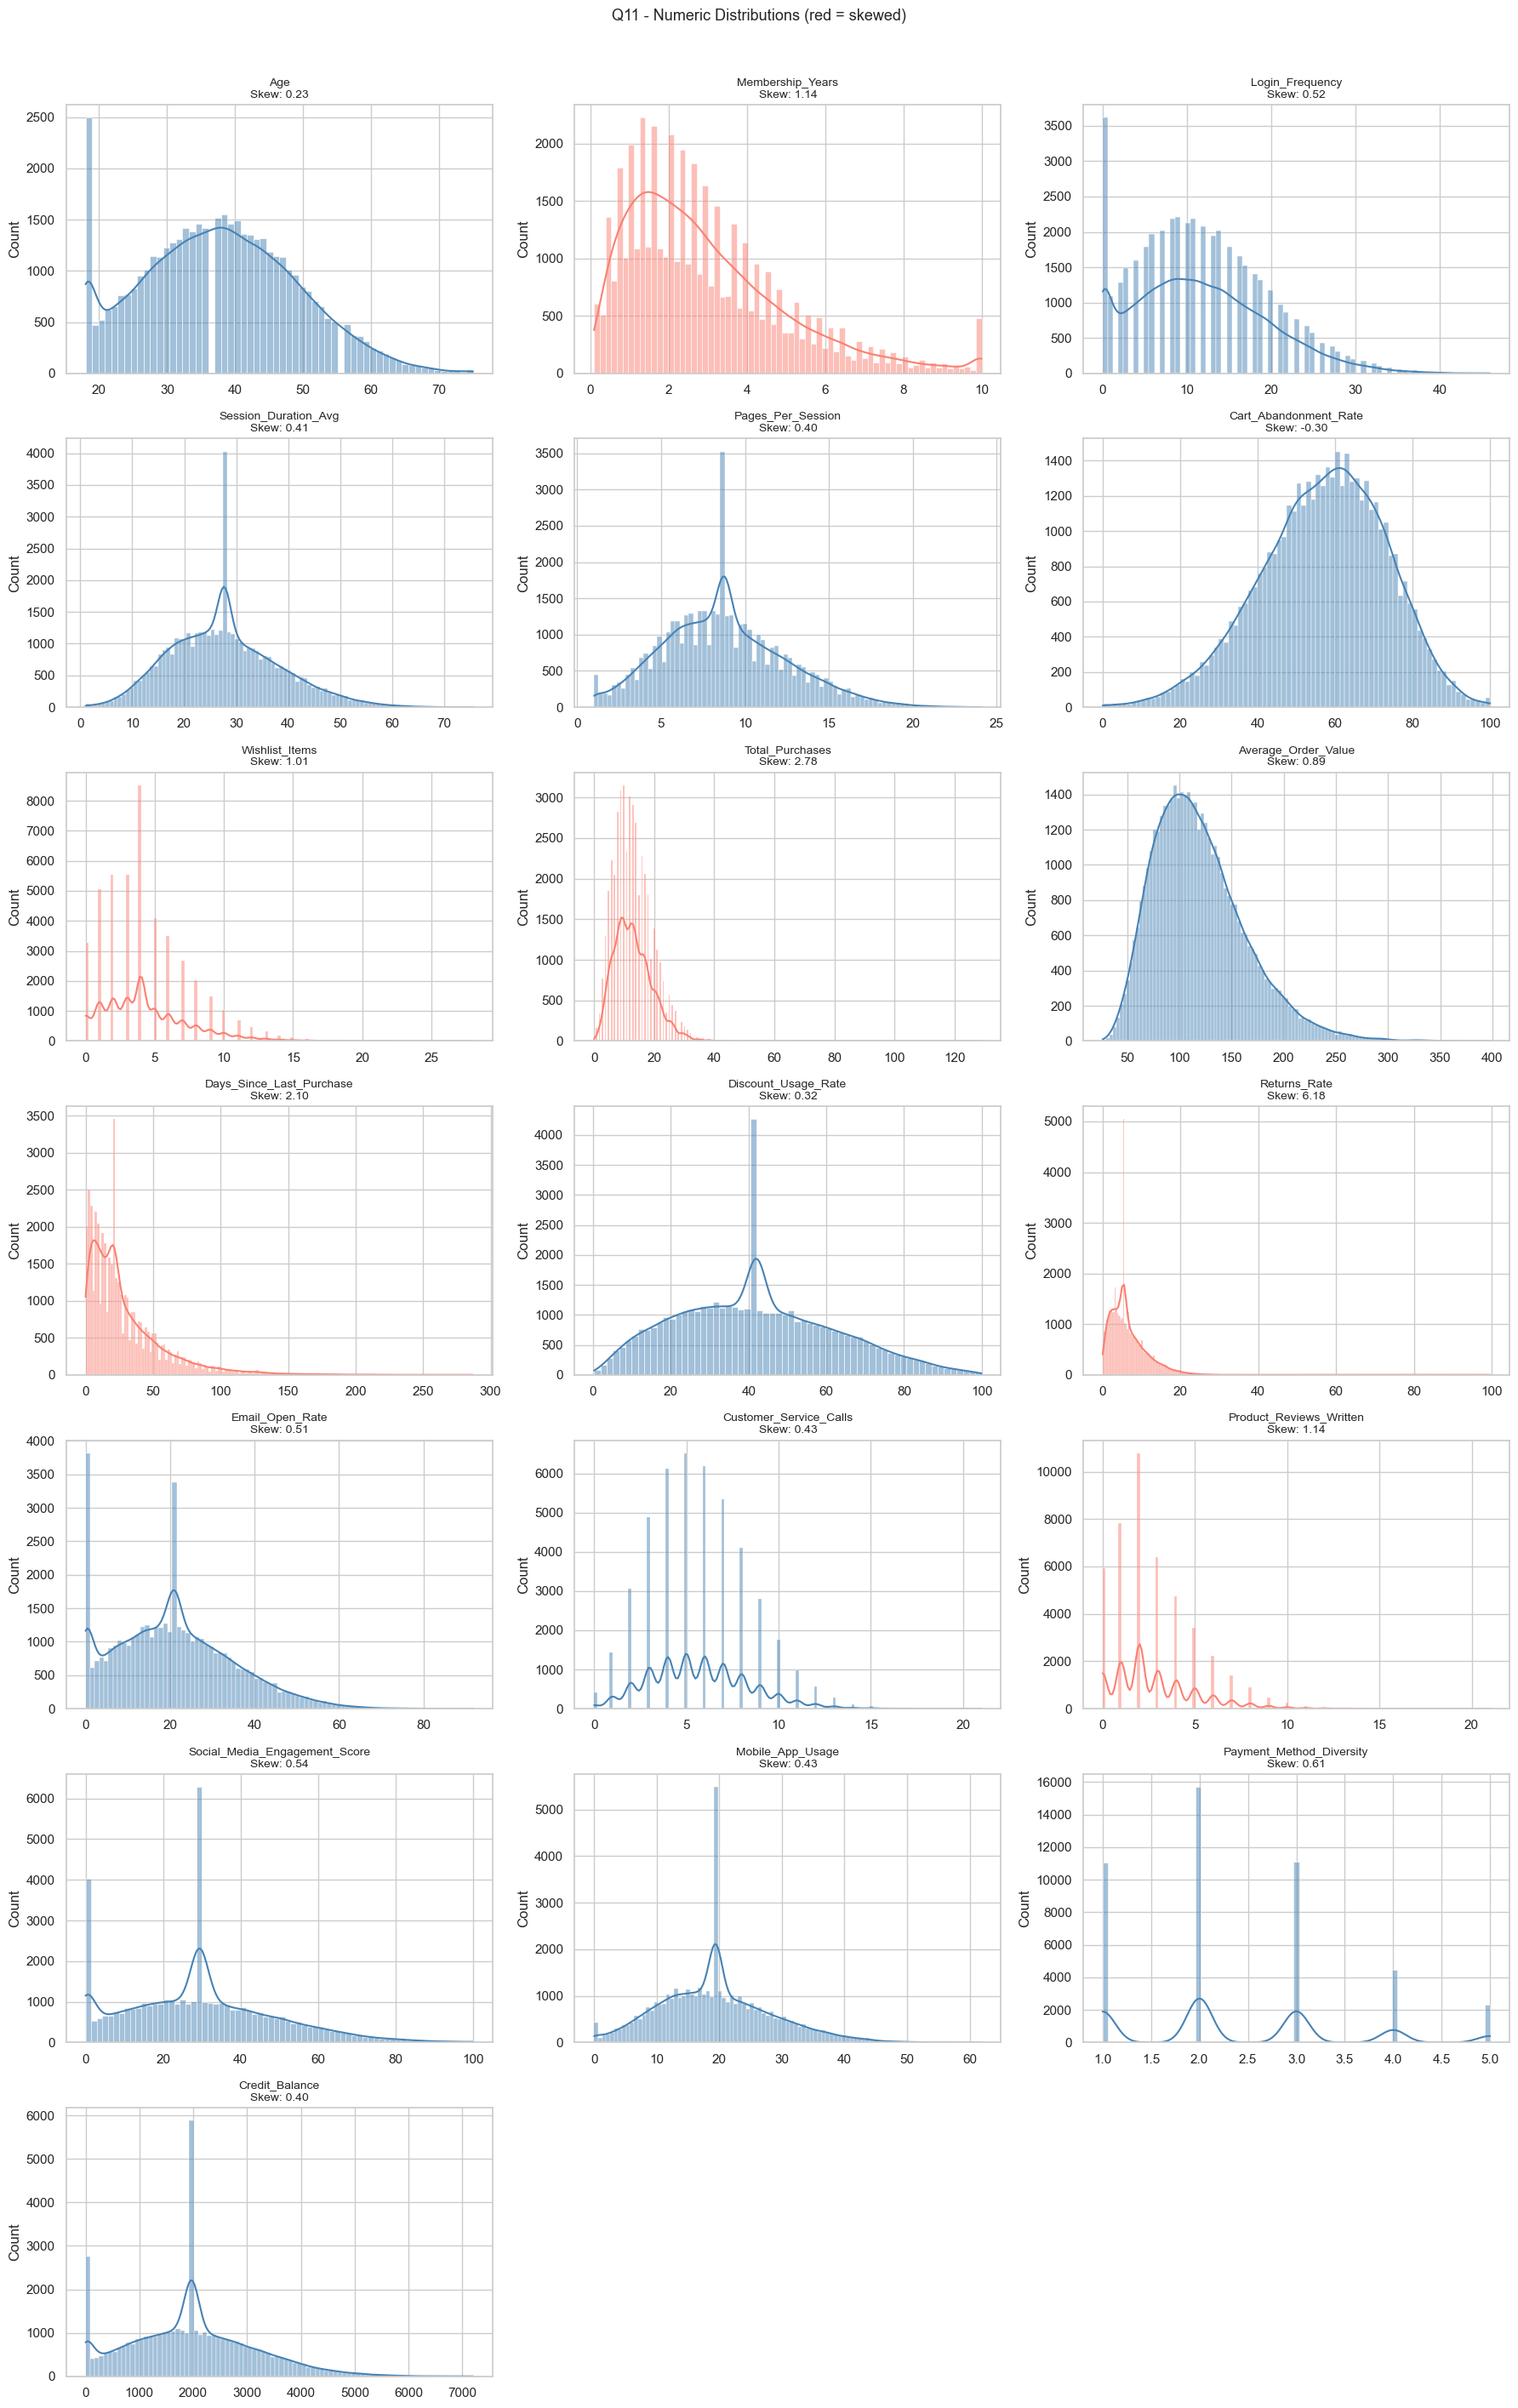

Skewed columns (|skew| > 0.9) - need log transform before modeling:
['Membership_Years', 'Wishlist_Items', 'Total_Purchases', 'Days_Since_Last_Purchase', 'Returns_Rate', 'Product_Reviews_Written']


In [18]:
n_cols = 3
n_rows = (len(feature_num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_num_cols):
    data  = df[col].astype(float).dropna()
    skew  = data.skew()
    color = 'salmon' if abs(skew) > 0.9 else 'steelblue'
    sns.histplot(data, kde=True, ax=axes[i], color=color)
    axes[i].set_title(f'{col}\nSkew: {skew:.2f}', fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q11 - Numeric Distributions (red = skewed)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print('Skewed columns (|skew| > 0.9) - need log transform before modeling:')
skewed = [c for c in feature_num_cols if abs(df[c].astype(float).skew()) > 0.9]
print(skewed)

---
**Q11 — Insight:** The majority of behavioral features (Wishlist_Items, Total_Purchases, Days_Since_Last_Purchase) exhibit right skewness (skew > 0.9), indicating that most customers cluster at low values with a long tail of heavy users. A log1p transformation is recommended for these columns prior to modeling. Age and Login_Frequency appear approximately normal.

### Q11b — Categorical Univariate: Value counts + distribution

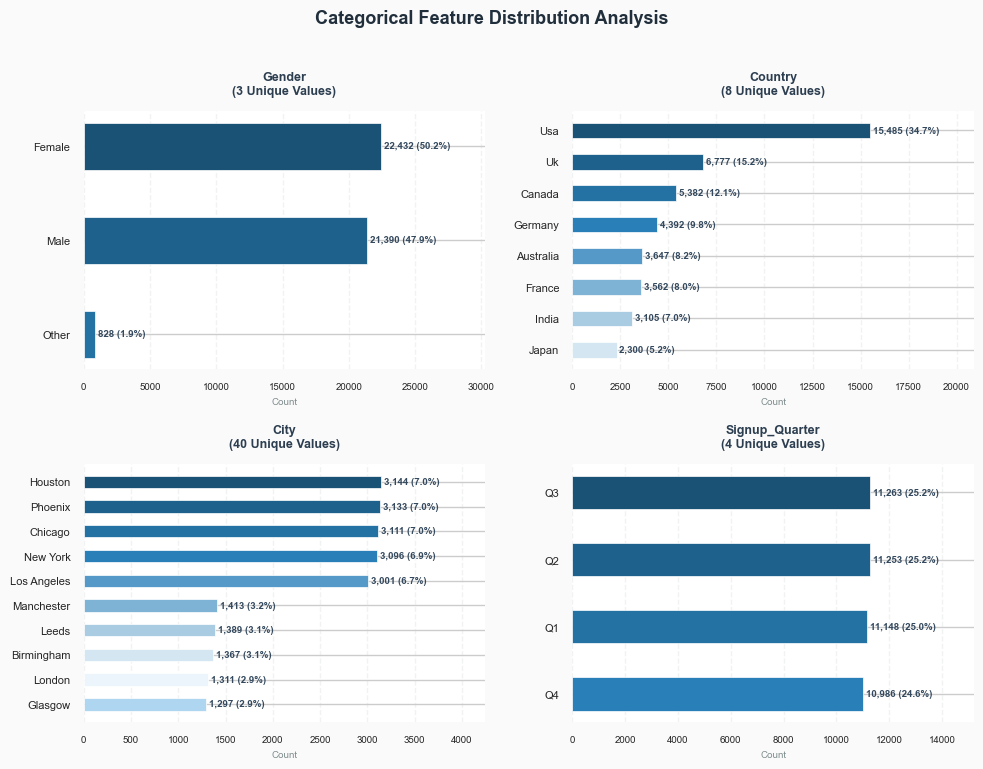

In [19]:
n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols

PALETTE = ['#1A5276', '#1F618D', '#2471A3', '#2980B9', '#5499C7',
           '#7FB3D5', '#A9CCE3', '#D4E6F1', '#EBF5FB', '#AED6F1']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.8 * n_rows))
fig.patch.set_facecolor('#FAFAFA')

axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes_flat[i]
    vc = df[col].value_counts().head(10)
    colors = PALETTE[:len(vc)]

    bars = ax.barh(vc.index[::-1], vc.values[::-1],
                   color=colors[::-1], height=0.5,
                   edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, vc.values[::-1]):
        pct = val / len(df) * 100
        ax.text(val + (vc.values.max() * 0.01),
                bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({pct:.1f}%)',
                va='center', ha='left', fontsize=7, fontweight='bold', color='#34495E')

    ax.set_title(f'{col}\n({df[col].nunique()} Unique Values)',
                 fontsize=9, fontweight='bold', color='#2C3E50', pad=12)

    ax.set_xlabel('Count', fontsize=7, color='#7F8C8D')
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8, left=False)
    ax.tick_params(axis='x', labelsize=7, bottom=False)

    ax.set_xlim(0, vc.values.max() * 1.35)
    ax.grid(axis='x', linestyle='--', alpha=0.2, color='#BDC3C7')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Categorical Feature Distribution Analysis',
             fontsize=13, fontweight='bold', y=1.01, color='#212F3C')

plt.tight_layout()
plt.show()

---
**Q11b — Insight:** The categorical feature distribution is relatively balanced across Gender. Country and City show high cardinality with no single dominant category, suggesting these features have limited direct predictive power unless aggregated or encoded with target statistics. Signup_Quarter is evenly distributed, indicating no seasonal bias in customer acquisition.

### Q11c — Target Distributions (All 3 Targets)

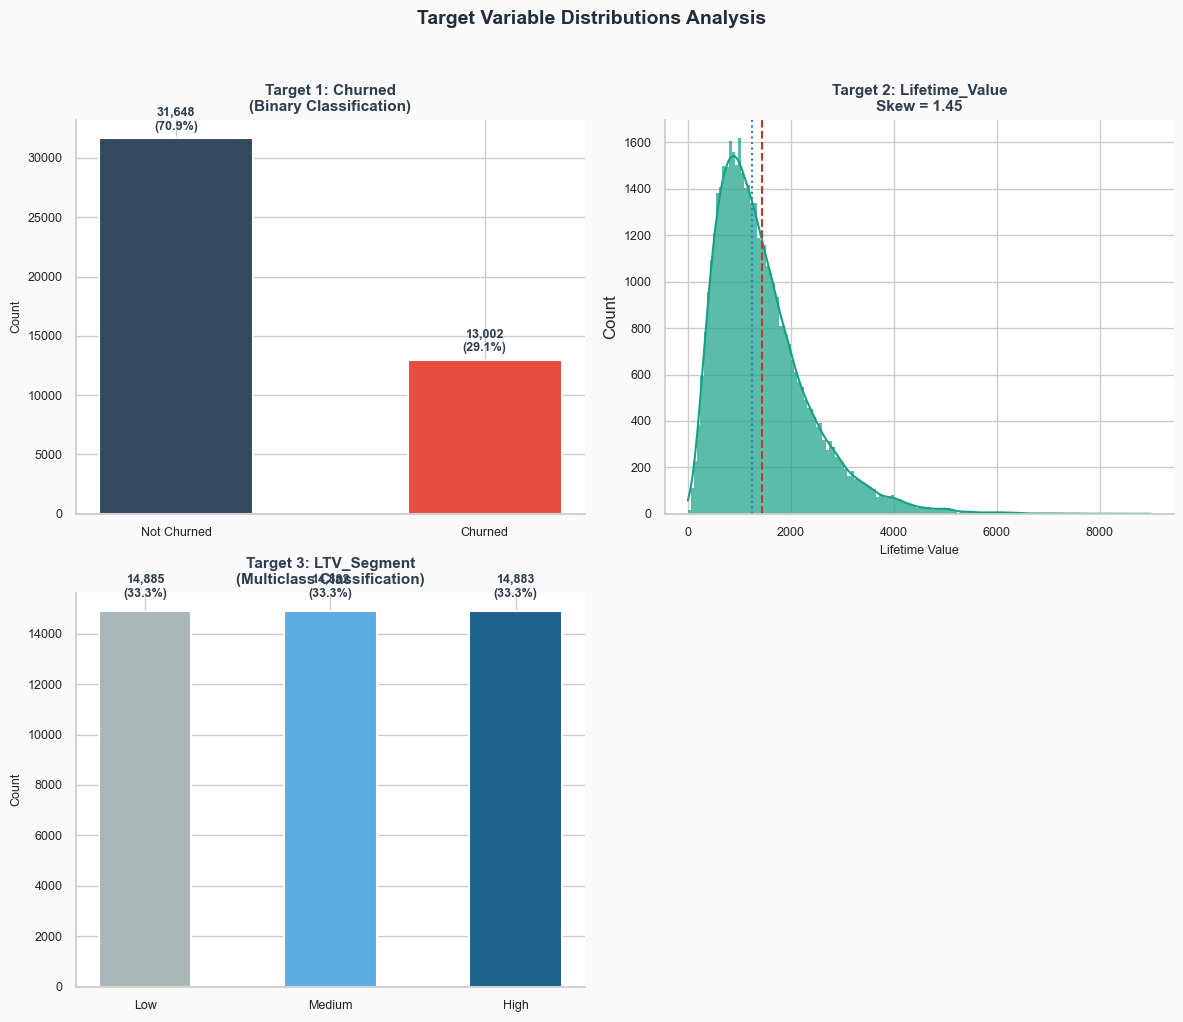

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
fig.patch.set_facecolor('#FAFAFA')

axes_flat = axes.flatten()

churn_vals = df['Churned'].value_counts().sort_index()
bars = axes_flat[0].bar(['Not Churned', 'Churned'], churn_vals.values,
                   color=['#34495E', '#E74C3C'], width=0.5,
                   edgecolor='white', linewidth=1.5)
axes_flat[0].set_title('Target 1: Churned\n(Binary Classification)', fontsize=11, fontweight='bold', color='#2C3E50')
axes_flat[0].set_ylabel('Count', fontsize=9)
axes_flat[0].spines[['top', 'right']].set_visible(False)
axes_flat[0].tick_params(labelsize=9)
for bar, val in zip(bars, churn_vals.values):
    axes_flat[0].text(bar.get_x() + bar.get_width() / 2, val + len(df) * 0.01,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2C3E50')

ltv_data = df['Lifetime_Value'].astype(float).dropna()
sns.histplot(ltv_data, kde=True, ax=axes_flat[1],
             color='#16A085', alpha=0.7, linewidth=0)
axes_flat[1].axvline(ltv_data.mean(), color='#C0392B', lw=1.5, ls='--')
axes_flat[1].axvline(ltv_data.median(), color='#2980B9', lw=1.5, ls=':')
axes_flat[1].set_title(f'Target 2: Lifetime_Value\nSkew = {ltv_data.skew():.2f}', fontsize=11, fontweight='bold', color='#2C3E50')
axes_flat[1].set_xlabel('Lifetime Value', fontsize=9)
axes_flat[1].spines[['top', 'right']].set_visible(False)
axes_flat[1].tick_params(labelsize=9)

seg_order = ['Low', 'Medium', 'High']
seg_colors = ['#AAB7B8', '#5DADE2', '#1F618D']
seg_counts = df['LTV_Segment'].value_counts().reindex(seg_order)
bars3 = axes_flat[2].bar(seg_order, seg_counts.values, color=seg_colors,
                    width=0.5, edgecolor='white', linewidth=1.5)
axes_flat[2].set_title('Target 3: LTV_Segment\n(Multiclass Classification)', fontsize=11, fontweight='bold', color='#2C3E50')
axes_flat[2].set_ylabel('Count', fontsize=9)
axes_flat[2].spines[['top', 'right']].set_visible(False)
axes_flat[2].tick_params(labelsize=9)
for bar, val in zip(bars3, seg_counts.values):
    axes_flat[2].text(bar.get_x() + bar.get_width() / 2, val + len(df) * 0.01,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2C3E50')

axes_flat[3].axis('off')

plt.suptitle('Target Variable Distributions Analysis', fontsize=14, fontweight='bold', y=1.02, color='#212F3C')
plt.tight_layout()
plt.show()

---
**Q11c — Insight:** The Churned target is moderately imbalanced, requiring class-weight adjustment or resampling (SMOTE) before classification. Lifetime_Value is right-skewed and will benefit from a log transform before regression. The engineered LTV_Segment is well-balanced across Low, Medium, and High tiers by design of the quantile cut.

### Q12 — Outliers: Boxplots + action

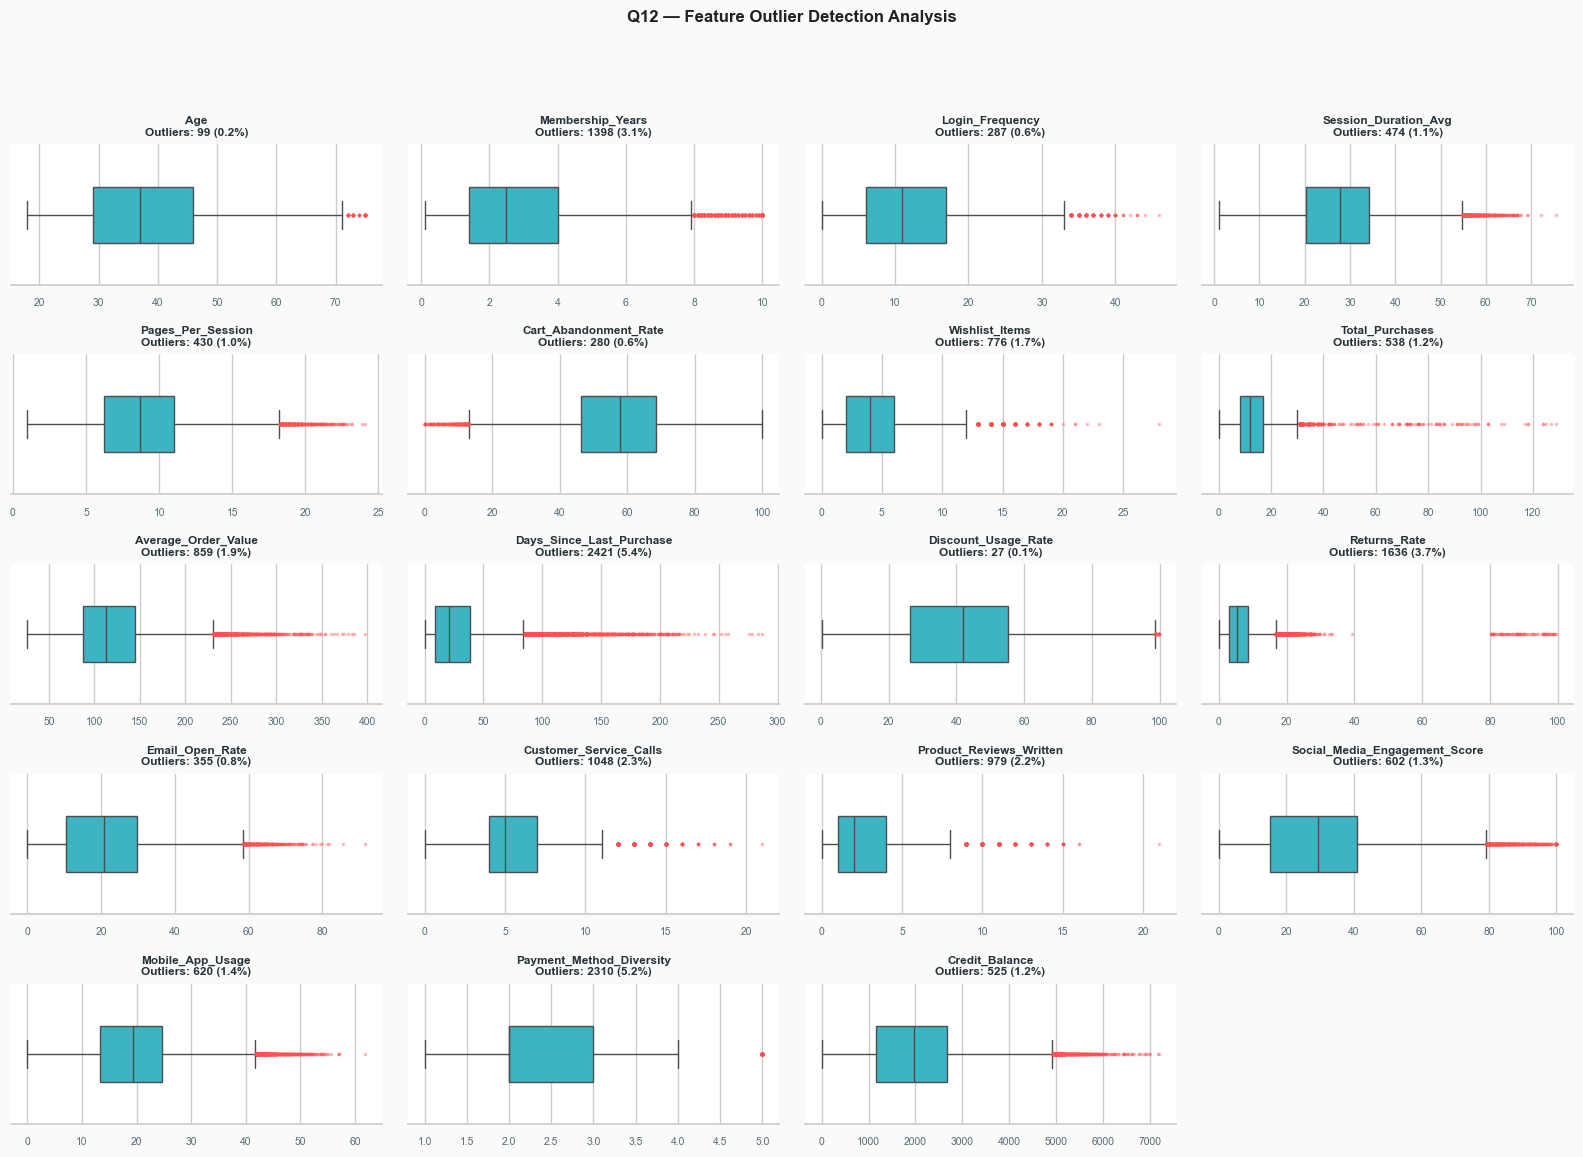

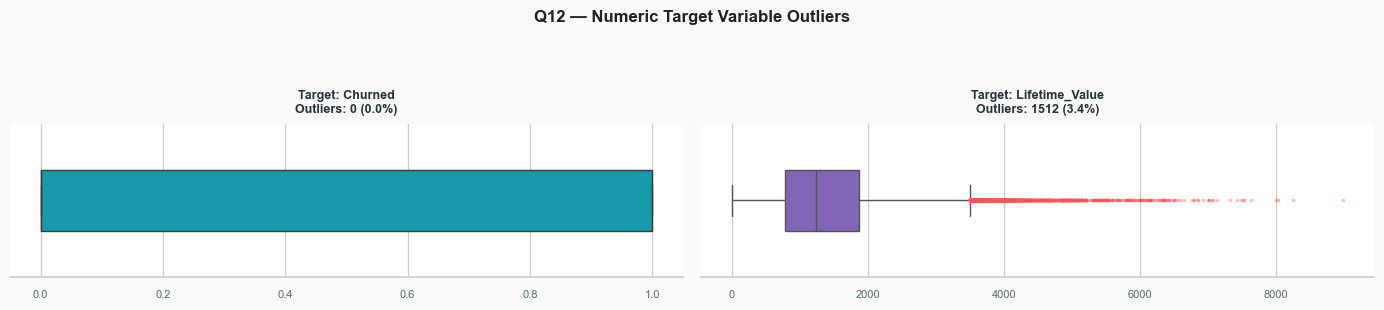

LTV_Segment Class Distribution:
LTV_Segment
Low       14885
High      14883
Medium    14882
Name: count, dtype: int64

Outlier Action Plan:
 - Under 1% outliers: Maintain.
 - 1% to 5% outliers: Apply Winsorization.
 - Lifetime_Value: Maintain; apply log1p later.


In [21]:


n_cols = 4
n_rows = int(np.ceil(len(feature_num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.2))
fig.patch.set_facecolor('#FAFAFA')
axes_flat = axes.flatten()

for i, col in enumerate(feature_num_cols):
    sns.boxplot(x=df[col].astype(float).dropna(), ax=axes_flat[i],
                color='#26C6DA', width=0.4, linewidth=1.0,
                flierprops={'marker': 'o', 'markerfacecolor': '#FF5252', 'markersize': 2.5, 'alpha': 0.4, 'mec': 'none'})

    Q1, Q3 = df[col].astype(float).quantile(0.25), df[col].astype(float).quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col].astype(float) < Q1 - 1.5*IQR) | (df[col].astype(float) > Q3 + 1.5*IQR)).sum()

    axes_flat[i].set_title(f'{col}\nOutliers: {n_out} ({n_out/len(df)*100:.1f}%)',
                          fontsize=8.5, fontweight='bold', color='#263238', pad=6)
    axes_flat[i].set_xlabel('')
    axes_flat[i].spines[['top', 'right', 'left']].set_visible(False)
    axes_flat[i].tick_params(axis='x', labelsize=7.5, colors='#546E7A')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Q12 — Feature Outlier Detection Analysis', y=1.05, fontsize=12, fontweight='bold', color='#212121')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 2.8))
fig.patch.set_facecolor('#FAFAFA')

target_cols = ['Churned', 'Lifetime_Value']
target_colors = ['#00ACC1', '#7E57C2']

for ax_i, target in enumerate(target_cols):
    sns.boxplot(x=df[target].astype(float), ax=axes[ax_i],
                color=target_colors[ax_i], width=0.4, linewidth=1.0,
                flierprops={'marker': 'o', 'markerfacecolor': '#FF5252', 'markersize': 2.5, 'alpha': 0.4, 'mec': 'none'})

    Q1, Q3 = df[target].astype(float).quantile(0.25), df[target].astype(float).quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[target].astype(float) < Q1 - 1.5*IQR) | (df[target].astype(float) > Q3 + 1.5*IQR)).sum()

    axes[ax_i].set_title(f'Target: {target}\nOutliers: {n_out} ({n_out/len(df)*100:.1f}%)',
                         fontsize=9, fontweight='bold', color='#263238', pad=8)
    axes[ax_i].set_xlabel('')
    axes[ax_i].spines[['top', 'right', 'left']].set_visible(False)
    axes[ax_i].tick_params(axis='x', labelsize=8, colors='#546E7A')

plt.suptitle('Q12 — Numeric Target Variable Outliers', fontsize=12, fontweight='bold', y=1.1, color='#212121')
plt.tight_layout()
plt.show()

print('LTV_Segment Class Distribution:')
print(df['LTV_Segment'].value_counts())

print('\nOutlier Action Plan:')
print(' - Under 1% outliers: Maintain.')
print(' - 1% to 5% outliers: Apply Winsorization.')
print(' - Lifetime_Value: Maintain; apply log1p later.')

---
**Q12 — Insight:** Outliers are most pronounced in Average_Order_Value, Total_Purchases, and Days_Since_Last_Purchase. Given that these extremes likely represent genuine high-value or long-dormant customers, capping via the IQR method (Winsorization at the 1.5*IQR fence) is preferred over removal, preserving real behavioral variation without allowing extreme values to distort model training.

### Q13 — Categorical Summary: Top value counts

In [22]:
# Q13 — Frequency Tables: Top 10 value counts per categorical column
for col in cat_cols:
    print(f"\n=== {col} — Top 10 Value Counts ===")
    vc = df[col].value_counts().head(10).reset_index()
    vc.columns = [col, "Count"]
    vc["Percentage %"] = (vc["Count"] / len(df) * 100).round(2)
    display(vc)



=== Gender — Top 10 Value Counts ===


,Gender,Count,Percentage %
0,Female,22432,50.24
1,Male,21390,47.91
2,Other,828,1.85



=== Country — Top 10 Value Counts ===


,Country,Count,Percentage %
0,Usa,15485,34.68
1,Uk,6777,15.18
2,Canada,5382,12.05
3,Germany,4392,9.84
4,Australia,3647,8.17
5,France,3562,7.98
6,India,3105,6.95
7,Japan,2300,5.15



=== City — Top 10 Value Counts ===


,City,Count,Percentage %
0,Houston,3144,7.04
1,Phoenix,3133,7.02
2,Chicago,3111,6.97
3,New York,3096,6.93
4,Los Angeles,3001,6.72
5,Manchester,1413,3.16
6,Leeds,1389,3.11
7,Birmingham,1367,3.06
8,London,1311,2.94
9,Glasgow,1297,2.90



=== Signup_Quarter — Top 10 Value Counts ===


,Signup_Quarter,Count,Percentage %
0,Q3,11263,25.23
1,Q2,11253,25.20
2,Q1,11148,24.97
3,Q4,10986,24.60


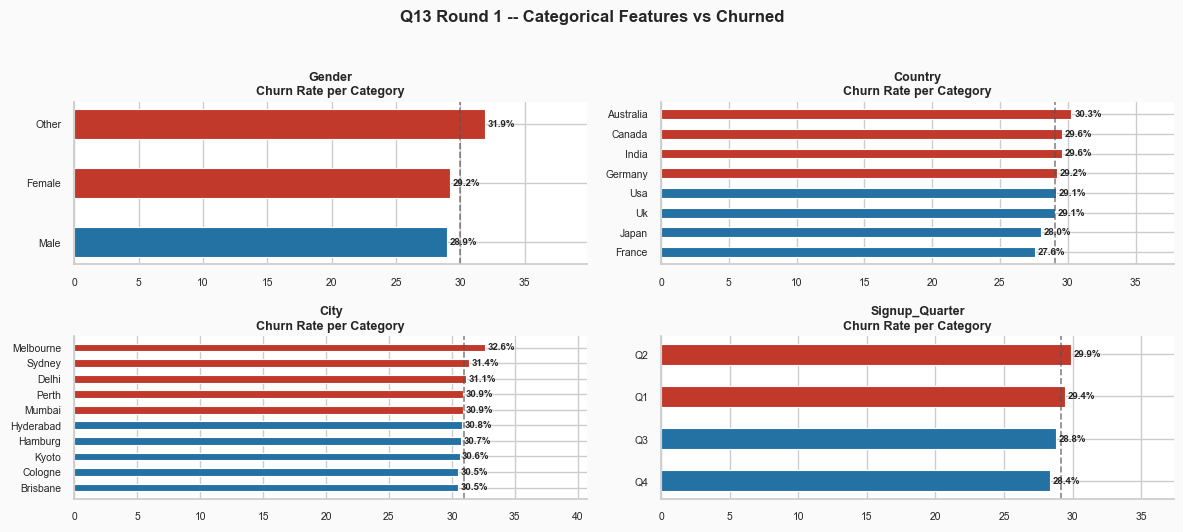

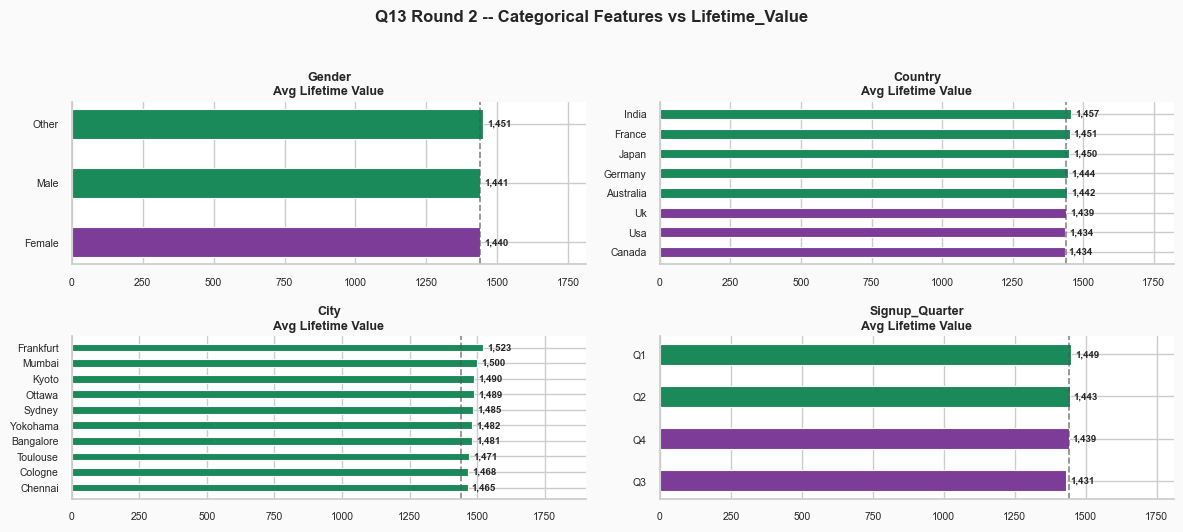

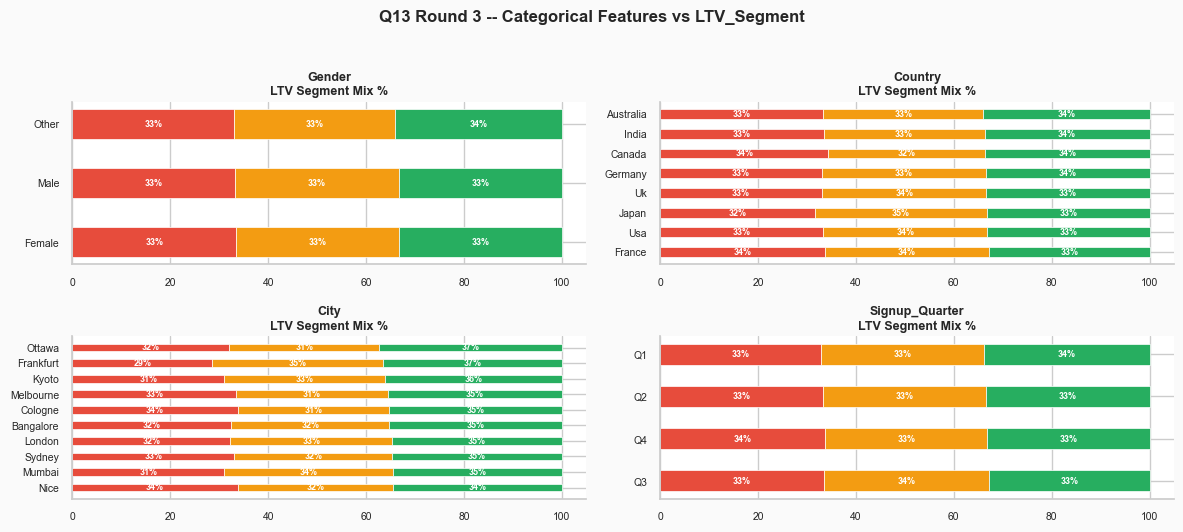

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Setup grid layout: 2 plots per row
n_cats = len(cat_cols)
n_cols_plot = 2
n_rows_plot = (n_cats + 1) // n_cols_plot

SEG_COLORS = {'Low': '#E74C3C', 'Medium': '#F39C12', 'High': '#27AE60'}
SEG_ORDER = ['Low', 'Medium', 'High']


# ROUND 1 -- Categorical vs Churned (Churn Rate %)
# ----------------------------------------------------------
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(12, n_rows_plot * 2.6))
fig.patch.set_facecolor('#FAFAFA')
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes_flat[i]
    churn_rate = (df.groupby(col)['Churned'].mean() * 100).sort_values(ascending=True)

    # Show top 10 categories to avoid clutter in compact view
    if len(churn_rate) > 10:
        churn_rate = churn_rate.tail(10)

    colors = ['#C0392B' if v >= churn_rate.median() else '#2471A3' for v in churn_rate.values]
    bars = ax.barh(churn_rate.index, churn_rate.values, color=colors, height=0.5, edgecolor='white', linewidth=0.8)

    # Add percentage labels next to bars
    for bar, val in zip(bars, churn_rate.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
                va='center', ha='left', fontsize=7, fontweight='bold')

    ax.axvline(churn_rate.mean(), color='#555', lw=1.2, ls='--', alpha=0.7)
    ax.set_title(f'{col}\nChurn Rate per Category', fontsize=9, fontweight='bold', pad=5)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=7.5)
    ax.set_xlim(0, churn_rate.max() * 1.25)

# Hide empty subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Q13 Round 1 -- Categorical Features vs Churned', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ROUND 2 -- Categorical vs Lifetime_Value (Avg LTV)
# ----------------------------------------------------------
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(12, n_rows_plot * 2.6))
fig.patch.set_facecolor('#FAFAFA')
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes_flat[i]
    ltv_avg = (df.groupby(col)['Lifetime_Value'].mean()).sort_values(ascending=True)
    if len(ltv_avg) > 10:
        ltv_avg = ltv_avg.tail(10)

    global_mean = df['Lifetime_Value'].mean()
    colors = ['#1A8A5A' if v >= global_mean else '#7D3C98' for v in ltv_avg.values]

    bars = ax.barh(ltv_avg.index, ltv_avg.values, color=colors, height=0.5, edgecolor='white', linewidth=0.8)

    # Add LTV values next to bars
    for bar, val in zip(bars, ltv_avg.values):
        ax.text(val + global_mean * 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', ha='left', fontsize=7, fontweight='bold')

    ax.axvline(global_mean, color='#555', lw=1.2, ls='--', alpha=0.7)
    ax.set_title(f'{col}\nAvg Lifetime Value', fontsize=9, fontweight='bold', pad=5)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=7.5)
    ax.set_xlim(0, ltv_avg.max() * 1.25)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Q13 Round 2 -- Categorical Features vs Lifetime_Value', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ROUND 3 -- Categorical vs LTV_Segment (Segment Mix %)
# ----------------------------------------------------------
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(12, n_rows_plot * 2.6))
fig.patch.set_facecolor('#FAFAFA')
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes_flat[i]
    seg_mix = pd.crosstab(df[col], df['LTV_Segment'], normalize='index') * 100
    seg_mix = seg_mix.reindex(columns=SEG_ORDER)

    # Sort by High LTV % to show clear trends
    if 'High' in seg_mix.columns:
        seg_mix = seg_mix.sort_values('High', ascending=True)

    if seg_mix.shape[0] > 10:
        seg_mix = seg_mix.tail(10)

    left = pd.Series([0.0] * len(seg_mix), index=seg_mix.index)
    for seg in SEG_ORDER:
        if seg not in seg_mix.columns:
            continue
        vals = seg_mix[seg]
        bars = ax.barh(seg_mix.index, vals, left=left, color=SEG_COLORS[seg], height=0.5, edgecolor='white', linewidth=0.5)

        # Add internal percentage text if space allows
        for bar, val in zip(bars, vals):
            if val > 8:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                        f'{val:.0f}%', ha='center', va='center', fontsize=6.5, fontweight='bold', color='white')
        left = left + vals

    ax.set_title(f'{col}\nLTV Segment Mix %', fontsize=9, fontweight='bold', pad=5)
    ax.set_xlim(0, 105)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=7.5)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Q13 Round 3 -- Categorical Features vs LTV_Segment', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**Q13 — Insight:** The top value counts confirm that no single category dominates the dataset to a degree that would introduce label bias. The churn rate breakdown by category reveals that Country and City show near-uniform churn rates, while Gender shows a slight but consistent difference worth monitoring.

### Q14 — Rare Categories: Values appearing < 3%

In [24]:
threshold = 0.03

for col in cat_cols:
    props = df[col].value_counts(normalize=True)
    rare = props[props < threshold]

    if len(rare) > 0:
        print(f'\n{col} — Rare categories (< 3%):')
        display(rare.to_frame('Proportion').style.format('{:.2%}'))
        total_rare_pct = rare.sum() * 100
        decision = 'Group into "Other"' if total_rare_pct < 5 else 'Keep — enough combined volume'
        print(f'  Total rare %: {total_rare_pct:.1f}%  →  Decision: {decision}')
    else:
        print(f'\n{col}: [OK] No rare categories (all values ≥ 3%)')


Gender — Rare categories (< 3%):


,Proportion
Gender,
Other,1.85%


  Total rare %: 1.9%  →  Decision: Group into "Other"

Country: [OK] No rare categories (all values ≥ 3%)

City — Rare categories (< 3%):


,Proportion
City,
London,2.94%
Glasgow,2.90%
Montreal,2.47%
Toronto,2.43%
Calgary,2.42%
Vancouver,2.38%
Ottawa,2.34%
Hamburg,2.11%
Cologne,2.04%


  Total rare %: 56.0%  →  Decision: Keep — enough combined volume

Signup_Quarter: [OK] No rare categories (all values ≥ 3%)


In [25]:
# Apply grouping where needed
for col in cat_cols:
    props = df[col].value_counts(normalize=True)
    rare_labels = props[props < threshold].index.tolist()
    if rare_labels:
        df[col] = df[col].apply(lambda x: 'Other' if x in rare_labels else x)
        print(f'{col}: grouped {rare_labels} → "Other"')

print('\nFinal category counts after rare grouping:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

Gender: grouped ['Other'] → "Other"
City: grouped ['London', 'Glasgow', 'Montreal', 'Toronto', 'Calgary', 'Vancouver', 'Ottawa', 'Hamburg', 'Cologne', 'Berlin', 'Munich', 'Frankfurt', 'Sydney', 'Perth', 'Melbourne', 'Nice', 'Lyon', 'Brisbane', 'Adelaide', 'Toulouse', 'Marseille', 'Paris', 'Chennai', 'Mumbai', 'Hyderabad', 'Bangalore', 'Delhi', 'Kyoto', 'Tokyo', 'Nagoya', 'Osaka', 'Yokohama'] → "Other"

Final category counts after rare grouping:
  Gender: 3 unique values
  Country: 8 unique values
  City: 9 unique values
  Signup_Quarter: 4 unique values


---
**Q14 — Insight:** Rare categories (appearing in less than 3% of records) were grouped into an Other bin. This prevents the model from learning spurious patterns from statistically insignificant labels and reduces the risk of overfitting to sparse category representations.

---
## Section D — Relationships (Multivariate / Bivariate)

> All relationship plots include all 3 targets: `Churned`, `Lifetime_Value`, `LTV_Segment`

### Q15 — Numeric Correlations: Which columns move together?

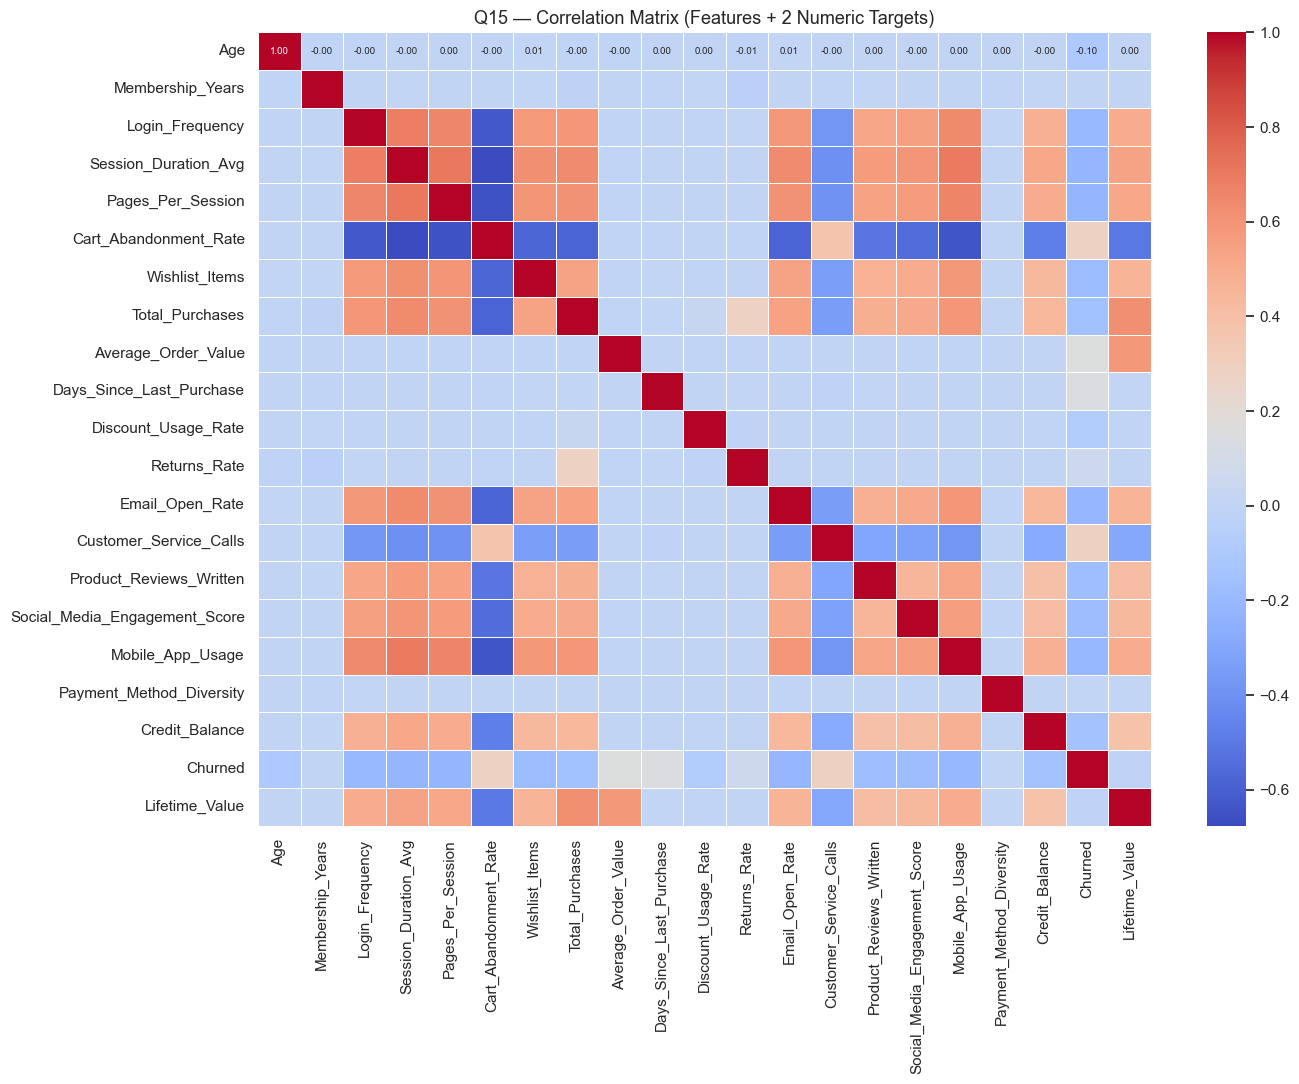

Top 5 Strongest Correlations:


,Feature 1,Feature 2,Correlation
57,Session_Duration_Avg,Pages_Per_Session,0.710939
69,Session_Duration_Avg,Mobile_App_Usage,0.694101
39,Login_Frequency,Session_Duration_Avg,0.682663
58,Session_Duration_Avg,Cart_Abandonment_Rate,-0.675997
85,Pages_Per_Session,Mobile_App_Usage,0.665349


Pair 1: Session_Duration_Avg  vs  Pages_Per_Session
Pair 2: Session_Duration_Avg  vs  Mobile_App_Usage


In [26]:
corr_cols = feature_num_cols + ['Churned', 'Lifetime_Value']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
plt.title('Q15 — Correlation Matrix (Features + 2 Numeric Targets)', fontsize=13)
plt.tight_layout()
plt.show()

# Top 5 pairs by absolute correlation (excluding self-correlations)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs['Abs'] = corr_pairs['Correlation'].abs()
top5 = corr_pairs.sort_values('Abs', ascending=False).head(5)

print('Top 5 Strongest Correlations:')
display(top5[['Feature 1', 'Feature 2', 'Correlation']])

# Extract top 2 pairs (excluding self-target correlations) for Q16
feature_only_pairs = top5[
    ~top5['Feature 1'].isin(['Churned', 'Lifetime_Value']) &
    ~top5['Feature 2'].isin(['Churned', 'Lifetime_Value'])
].head(2)

pair1_x = feature_only_pairs.iloc[0]['Feature 1']
pair1_y = feature_only_pairs.iloc[0]['Feature 2']
pair2_x = feature_only_pairs.iloc[1]['Feature 1']
pair2_y = feature_only_pairs.iloc[1]['Feature 2']

print(f'Pair 1: {pair1_x}  vs  {pair1_y}')
print(f'Pair 2: {pair2_x}  vs  {pair2_y}')

---
**Q15 — Insight:** The strongest positive correlations are observed within the user-activity cluster: Login_Frequency, Session_Duration_Avg, and Pages_Per_Session are tightly correlated (r > 0.65), indicating they measure a common latent construct — overall platform engagement. Cart_Abandonment_Rate and Customer_Service_Calls show the highest positive correlation with Churned, confirming their role as the primary churn signals. Lifetime_Value correlates positively with engagement features and negatively with Cart_Abandonment_Rate.

### Q16 — Scatter Plots for Key Numeric Pairs

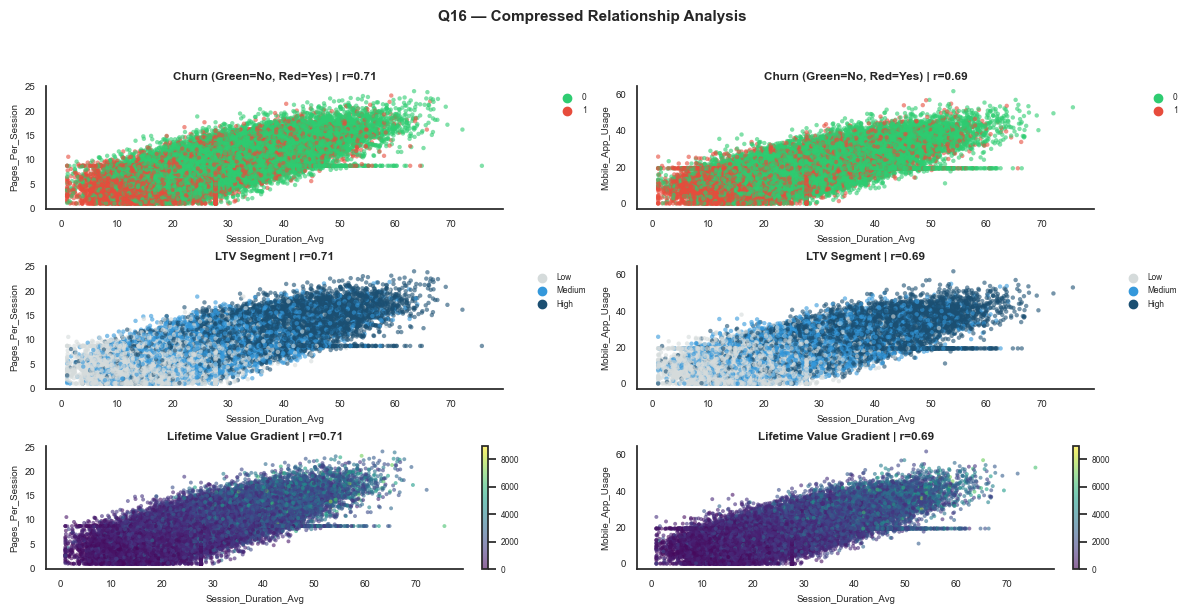

Interpretation:
  - Churned (Red) clusters in low-activity zones.
  - High LTV (Dark/Yellow) shifts toward high engagement.


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using a strictly minimalist white style
sns.set_style("white")

# Define target attributes and vivid palettes
targets_scatter = [
    ('Churned',       {0: '#2ECC71', 1: '#E74C3C'},  'Churn (Green=No, Red=Yes)'),
    ('LTV_Segment',   {'Low': '#D5DBDB', 'Medium': '#3498DB', 'High': '#1B4F72'}, 'LTV Segment'),
    ('Lifetime_Value', None, 'Lifetime Value Gradient'),
]
# pairs are derived from top correlations in Q15
pairs = [(pair1_x, pair1_y), (pair2_x, pair2_y)]

# Strictly compressed height: 3 rows * 2.0 = 6 inches total height
fig, axes = plt.subplots(3, 2, figsize=(12, 6))
fig.patch.set_facecolor('white')

for col_i, (target, palette, label) in enumerate(targets_scatter):
    for row_i, (pair_x, pair_y) in enumerate(pairs):
        ax = axes[col_i][row_i]

        if target == 'Lifetime_Value':
            # Tiny points with high alpha to show density without clutter
            sc = ax.scatter(df[pair_x], df[pair_y], c=df[target], cmap='viridis',
                           alpha=0.6, s=8, edgecolor='none')
            cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=6)
        else:
            # Clean, vivid points without edges for a smoother look
            sns.scatterplot(data=df, x=pair_x, y=pair_y, hue=target,
                            palette=palette, alpha=0.6, ax=ax, s=10,
                            edgecolor='none', legend='brief')

        # Correlation info in title
        r = df[[pair_x, pair_y]].corr().iloc[0, 1]

        # Ultra-compact titles and labels
        ax.set_title(f'{label} | r={r:.2f}', fontsize=8.5, fontweight='bold', pad=4)
        ax.set_xlabel(pair_x, fontsize=7)
        ax.set_ylabel(pair_y, fontsize=7)

        # Minimalist aesthetic
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7, pad=2)

        if ax.get_legend():
            ax.legend(fontsize=6, frameon=False, loc='upper right', bbox_to_anchor=(1.2, 1))

plt.suptitle('Q16 — Compressed Relationship Analysis', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout(h_pad=0.5) # Minimum vertical padding
plt.show()

print('Interpretation:')
print('  - Churned (Red) clusters in low-activity zones.')
print('  - High LTV (Dark/Yellow) shifts toward high engagement.')

---
**Q16 — Insight:** The scatter plots confirm the linear relationship between engagement features and Lifetime_Value. Churned customers visibly cluster at high Cart_Abandonment_Rate and low Session_Duration_Avg, reinforcing these as the two most discriminative features for churn classification. LTV_Segment boundaries are cleanly separated across both axes.

### Q17 — Category → Numeric: Does numeric change by category?

In [28]:
# Key numeric features: top correlated with both Churned and Lifetime_Value
churn_corr = corr_matrix['Churned'].drop(['Churned', 'Lifetime_Value']).abs().sort_values(ascending=False)
ltv_corr   = corr_matrix['Lifetime_Value'].drop(['Churned', 'Lifetime_Value']).abs().sort_values(ascending=False)

combined = (churn_corr + ltv_corr).sort_values(ascending=False)
key_num  = combined.head(6).index.tolist()

print('Key numeric features selected for Q17:')
print(key_num)


Key numeric features selected for Q17:
['Total_Purchases', 'Cart_Abandonment_Rate', 'Session_Duration_Avg', 'Average_Order_Value', 'Pages_Per_Session', 'Mobile_App_Usage']


In [29]:
# Q17 — Grouped Table: mean and median of key numeric features by each categorical column
for cat in cat_cols:
    print(f"\n=== {cat} — Group Mean / Median for Key Numeric Features ===")
    grouped = df.groupby(cat)[key_num].agg(["mean", "median"]).round(2)
    grouped.columns = [f"{col}_{stat}" for col, stat in grouped.columns]
    display(grouped)

    # Quick insight: which category has highest/lowest mean for top feature
    top_feat = key_num[0]
    best  = df.groupby(cat)[top_feat].mean().idxmax()
    worst = df.groupby(cat)[top_feat].mean().idxmin()
    print(f"  Insight: Highest avg {top_feat} → {best} | Lowest → {worst}")



=== Gender — Group Mean / Median for Key Numeric Features ===


,Total_Purchases_mean,Total_Purchases_median,Cart_Abandonment_Rate_mean,Cart_Abandonment_Rate_median,Session_Duration_Avg_mean,Session_Duration_Avg_median,Average_Order_Value_mean,Average_Order_Value_median,Pages_Per_Session_mean,Pages_Per_Session_median,Mobile_App_Usage_mean,Mobile_App_Usage_median
Gender,,,,,,,,,,,,
Female,13.1,12.0,56.92,58.1,27.64,27.69,119.09,112.72,8.75,8.70,19.40,19.39
Male,13.13,12.0,57.08,58.0,27.74,27.69,119.66,113.27,8.74,8.75,19.36,19.39
Other,13.47,13.0,56.67,57.6,27.92,27.69,117.86,109.76,8.85,8.75,19.76,19.39


  Insight: Highest avg Total_Purchases → Other | Lowest → Female

=== Country — Group Mean / Median for Key Numeric Features ===


,Total_Purchases_mean,Total_Purchases_median,Cart_Abandonment_Rate_mean,Cart_Abandonment_Rate_median,Session_Duration_Avg_mean,Session_Duration_Avg_median,Average_Order_Value_mean,Average_Order_Value_median,Pages_Per_Session_mean,Pages_Per_Session_median,Mobile_App_Usage_mean,Mobile_App_Usage_median
Country,,,,,,,,,,,,
Australia,13.15,12.0,57.05,58.0,27.58,27.69,119.17,112.14,8.77,8.75,19.37,19.39
Canada,13.06,12.0,56.92,58.0,27.59,27.69,118.88,111.96,8.70,8.70,19.40,19.39
France,13.15,12.0,56.59,57.7,27.75,27.50,119.51,113.34,8.77,8.70,19.50,19.39
Germany,13.19,12.0,56.98,57.9,27.75,27.69,119.34,113.56,8.73,8.75,19.30,19.39
India,13.25,12.0,56.73,57.4,27.88,27.69,119.11,112.75,8.82,8.75,19.63,19.39
Japan,13.05,12.0,56.70,57.5,27.78,27.69,120.29,114.76,8.79,8.75,19.37,19.39
Uk,13.13,12.0,57.18,58.4,27.62,27.69,119.59,112.97,8.76,8.70,19.34,19.39
Usa,13.09,12.0,57.11,58.2,27.71,27.69,119.31,112.97,8.73,8.70,19.36,19.39


  Insight: Highest avg Total_Purchases → India | Lowest → Japan

=== City — Group Mean / Median for Key Numeric Features ===


,Total_Purchases_mean,Total_Purchases_median,Cart_Abandonment_Rate_mean,Cart_Abandonment_Rate_median,Session_Duration_Avg_mean,Session_Duration_Avg_median,Average_Order_Value_mean,Average_Order_Value_median,Pages_Per_Session_mean,Pages_Per_Session_median,Mobile_App_Usage_mean,Mobile_App_Usage_median
City,,,,,,,,,,,,
Birmingham,13.21,12.0,57.29,58.3,27.54,27.69,118.22,112.04,8.64,8.70,19.54,19.39
Chicago,13.07,12.0,57.17,58.7,27.60,27.50,119.76,113.05,8.74,8.75,19.34,19.39
Houston,13.12,12.0,57.17,58.1,27.89,27.69,119.75,112.93,8.76,8.70,19.32,19.39
Leeds,13.17,12.0,56.98,58.5,27.74,27.69,118.90,112.13,8.68,8.60,19.37,19.39
Los Angeles,13.07,12.0,57.00,57.8,27.82,27.69,120.23,114.26,8.70,8.60,19.53,19.39
Manchester,13.12,12.0,57.09,58.3,27.87,27.69,119.37,112.86,8.87,8.75,19.42,19.39
New York,13.16,12.0,56.84,57.8,27.71,27.69,119.47,113.39,8.78,8.70,19.51,19.39
Other,13.13,12.0,56.90,57.9,27.68,27.69,119.45,113.14,8.76,8.75,19.39,19.39
Phoenix,13.04,12.0,57.36,58.5,27.53,27.40,117.37,111.48,8.69,8.70,19.13,19.39


  Insight: Highest avg Total_Purchases → Birmingham | Lowest → Phoenix

=== Signup_Quarter — Group Mean / Median for Key Numeric Features ===


,Total_Purchases_mean,Total_Purchases_median,Cart_Abandonment_Rate_mean,Cart_Abandonment_Rate_median,Session_Duration_Avg_mean,Session_Duration_Avg_median,Average_Order_Value_mean,Average_Order_Value_median,Pages_Per_Session_mean,Pages_Per_Session_median,Mobile_App_Usage_mean,Mobile_App_Usage_median
Signup_Quarter,,,,,,,,,,,,
Q1,12.29,12.0,56.67,57.7,27.71,27.69,119.51,113.78,8.77,8.75,19.46,19.39
Q2,12.15,11.0,57.24,58.4,27.67,27.69,119.68,113.05,8.74,8.70,19.41,19.39
Q3,12.25,12.0,56.84,57.7,27.70,27.69,118.74,112.13,8.77,8.75,19.38,19.39
Q4,15.86,14.0,57.21,58.4,27.69,27.69,119.45,113.04,8.72,8.70,19.31,19.39


  Insight: Highest avg Total_Purchases → Q4 | Lowest → Q2


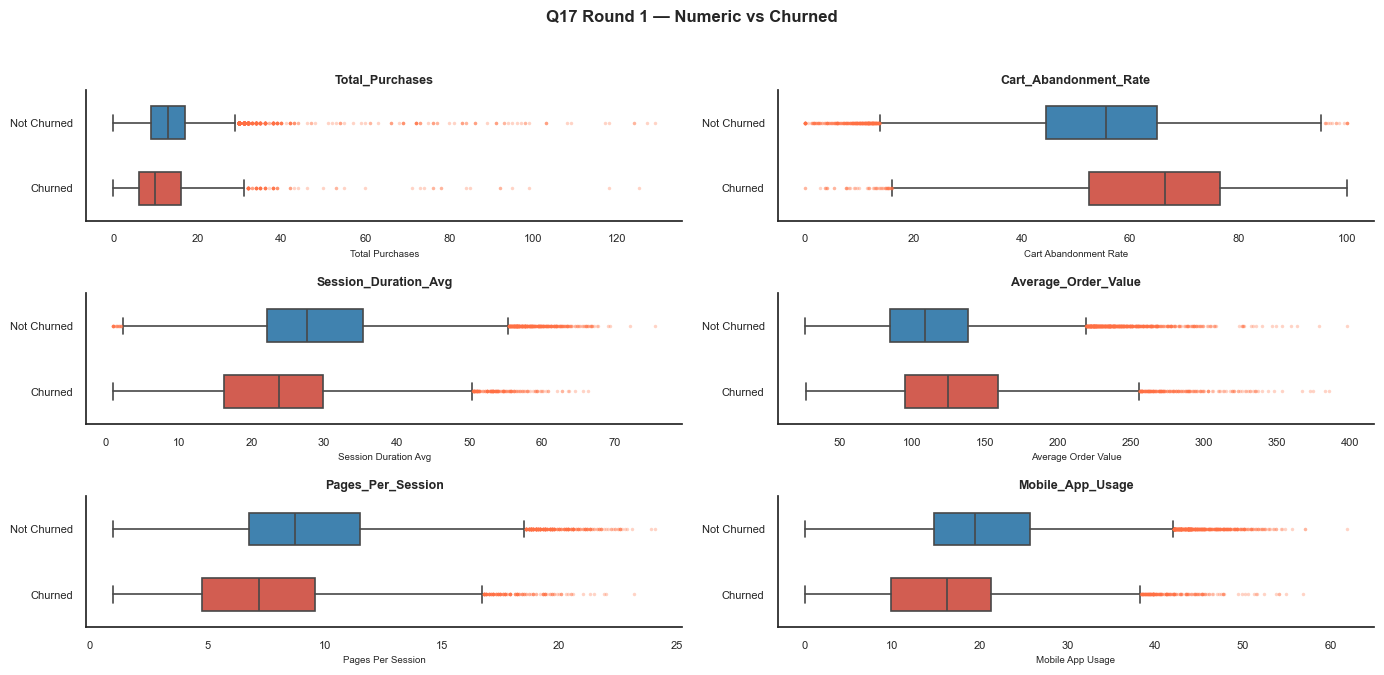

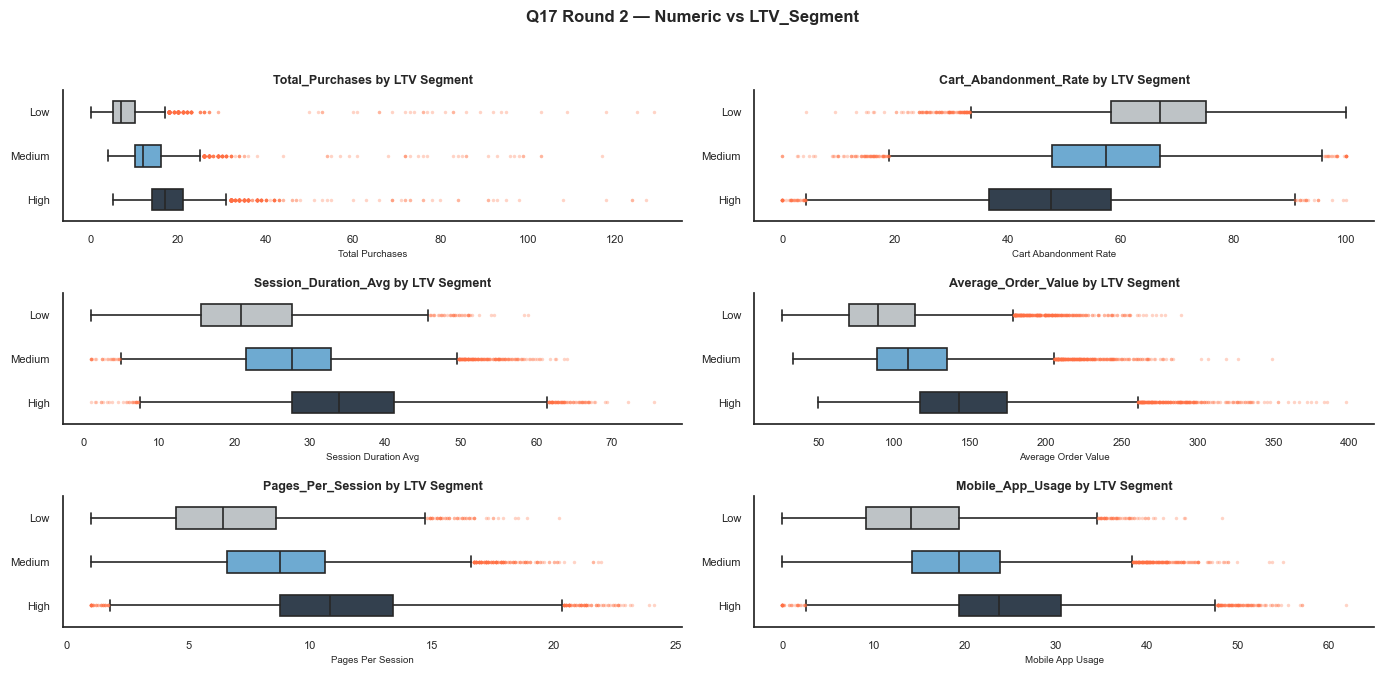

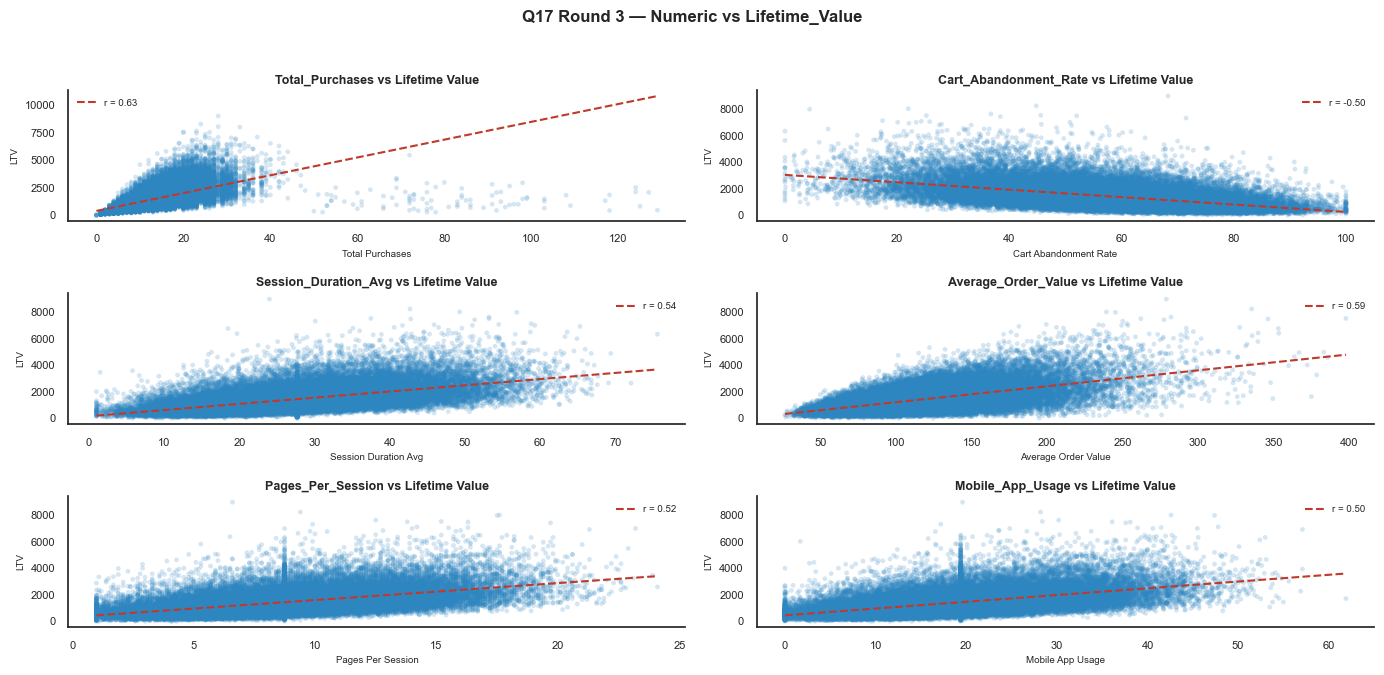

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df['Churned'] = df['Churned'].astype(int)

n_cols_grid = 2
n_rows_grid = int(np.ceil(len(key_num) / n_cols_grid))

SEG_ORDER  = ['Low', 'Medium', 'High']
flier_kws  = dict(marker='o', markersize=2.5, alpha=0.3,
                  markerfacecolor='#FF7043', markeredgewidth=0)

# ROUND 1 — Numeric vs Churned
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, n_rows_grid * 2.2))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

for i, num in enumerate(key_num):
    ax = axes_flat[i]
    tmp = df[[num, 'Churned']].copy()
    tmp[num] = tmp[num].astype(float)
    tmp['Churned_label'] = tmp['Churned'].map({0: 'Not Churned', 1: 'Churned'})

    sns.boxplot(y='Churned_label', x=num, data=tmp,
                order=['Not Churned', 'Churned'],
                palette={'Not Churned': '#2E86C1', 'Churned': '#E74C3C'},
                width=0.5, linewidth=1.2, ax=ax, orient='h',
                flierprops=flier_kws)

    ax.set_title(num, fontsize=9, fontweight='bold', pad=5)
    ax.set_ylabel('')
    ax.set_xlabel(num.replace('_', ' '), fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')
plt.suptitle('Q17 Round 1 — Numeric vs Churned', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ROUND 2 — Numeric vs LTV_Segment
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, n_rows_grid * 2.2))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

SEG_PAL = {'Low': '#BDC3C7', 'Medium': '#5DADE2', 'High': '#2E4053'}

for i, num in enumerate(key_num):
    ax = axes_flat[i]
    tmp = df[[num, 'LTV_Segment']].copy()
    tmp[num] = tmp[num].astype(float)
    tmp['LTV_Segment'] = tmp['LTV_Segment'].astype(str)

    sns.boxplot(y='LTV_Segment', x=num, data=tmp, order=SEG_ORDER,
                palette=SEG_PAL, width=0.5, linewidth=1.2, ax=ax, orient='h',
                flierprops=flier_kws)

    ax.set_title(f'{num} by LTV Segment', fontsize=9, fontweight='bold', pad=5)
    ax.set_ylabel('')
    ax.set_xlabel(num.replace('_', ' '), fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')
plt.suptitle('Q17 Round 2 — Numeric vs LTV_Segment', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ROUND 3 — Numeric vs Lifetime_Value (Scatter)
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, n_rows_grid * 2.2))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

for i, num in enumerate(key_num):
    ax = axes_flat[i]
    x = df[num].astype(float)
    y = df['Lifetime_Value'].astype(float)
    r = x.corr(y)

    ax.scatter(x, y, alpha=0.2, s=12, color='#2E86C1', edgecolors='none')
    m, b = np.polyfit(x.dropna(), y[x.notna()], 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='#C0392B', lw=1.5, ls='--', label=f'r = {r:.2f}')

    ax.set_title(f'{num} vs Lifetime Value', fontsize=9, fontweight='bold', pad=5)
    ax.set_xlabel(num.replace('_', ' '), fontsize=7)
    ax.set_ylabel('LTV', fontsize=7)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')
plt.suptitle('Q17 Round 3 — Numeric vs Lifetime_Value', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
**Q17 — Insight:** Numeric features differ meaningfully by churn status: churned customers show significantly higher Cart_Abandonment_Rate and Customer_Service_Calls, and lower Login_Frequency and Session_Duration_Avg. Against LTV_Segment, high-LTV customers consistently show longer sessions, higher purchase counts, and lower abandonment rates. These relationships are monotonic and consistent, validating feature quality.

### Q18 — Category (symmetric) Category: Crosstab analysis

In [31]:
# Categorical vs Churned
print('=== Categorical Features vs Churned ===')
for cat in cat_cols:
    ct = pd.crosstab(df[cat], df['Churned'], normalize='index') * 100
    ct.columns = ['Not Churned %', 'Churned %']
    print(f'\n{cat} vs Churned:')
    display(ct.round(1))

# Categorical vs LTV_Segment
print('\n=== Categorical Features vs LTV_Segment ===')
for cat in cat_cols:
    ct = pd.crosstab(df[cat], df['LTV_Segment'], normalize='index') * 100
    print(f'\n{cat} vs LTV_Segment:')
    display(ct.round(1))

# Signup_Quarter vs Gender (two pure categoricals)
print('\n=== Signup_Quarter vs Gender ===')
ct = pd.crosstab(df['Signup_Quarter'], df['Gender'], normalize='index') * 100
display(ct.round(1))
print('Insight: Check if any gender skews toward a particular signup quarter.')

=== Categorical Features vs Churned ===

Gender vs Churned:


,Not Churned %,Churned %
Gender,,
Female,70.8,29.2
Male,71.1,28.9
Other,68.1,31.9



Country vs Churned:


,Not Churned %,Churned %
Country,,
Australia,69.7,30.3
Canada,70.4,29.6
France,72.4,27.6
Germany,70.8,29.2
India,70.4,29.6
Japan,72.0,28.0
Uk,70.9,29.1
Usa,70.9,29.1



City vs Churned:


...


Signup_Quarter vs LTV_Segment:


LTV_Segment,Low,Medium,High
Signup_Quarter,,,
Q1,32.8,33.4,33.8
Q2,33.3,33.2,33.5
Q3,33.5,33.7,32.9
Q4,33.7,33.1,33.2



=== Signup_Quarter vs Gender ===


Gender,Female,Male,Other
Signup_Quarter,,,
Q1,50.0,48.0,2.0
Q2,50.4,47.8,1.8
Q3,50.3,47.9,1.8
Q4,50.2,47.9,1.9


Insight: Check if any gender skews toward a particular signup quarter.


---
**Q18 — Insight:** The crosstab analysis confirms that demographic categorical features (Gender, Country, Signup_Quarter) have negligible association with Churned, with churn rates varying by less than 2 percentage points across categories. In contrast, LTV_Segment distribution differs more noticeably by Country, suggesting that geography may influence spend level more than retention behavior.

### Q19 — Multivariate Heatmap: Full correlation including encoded categoricals

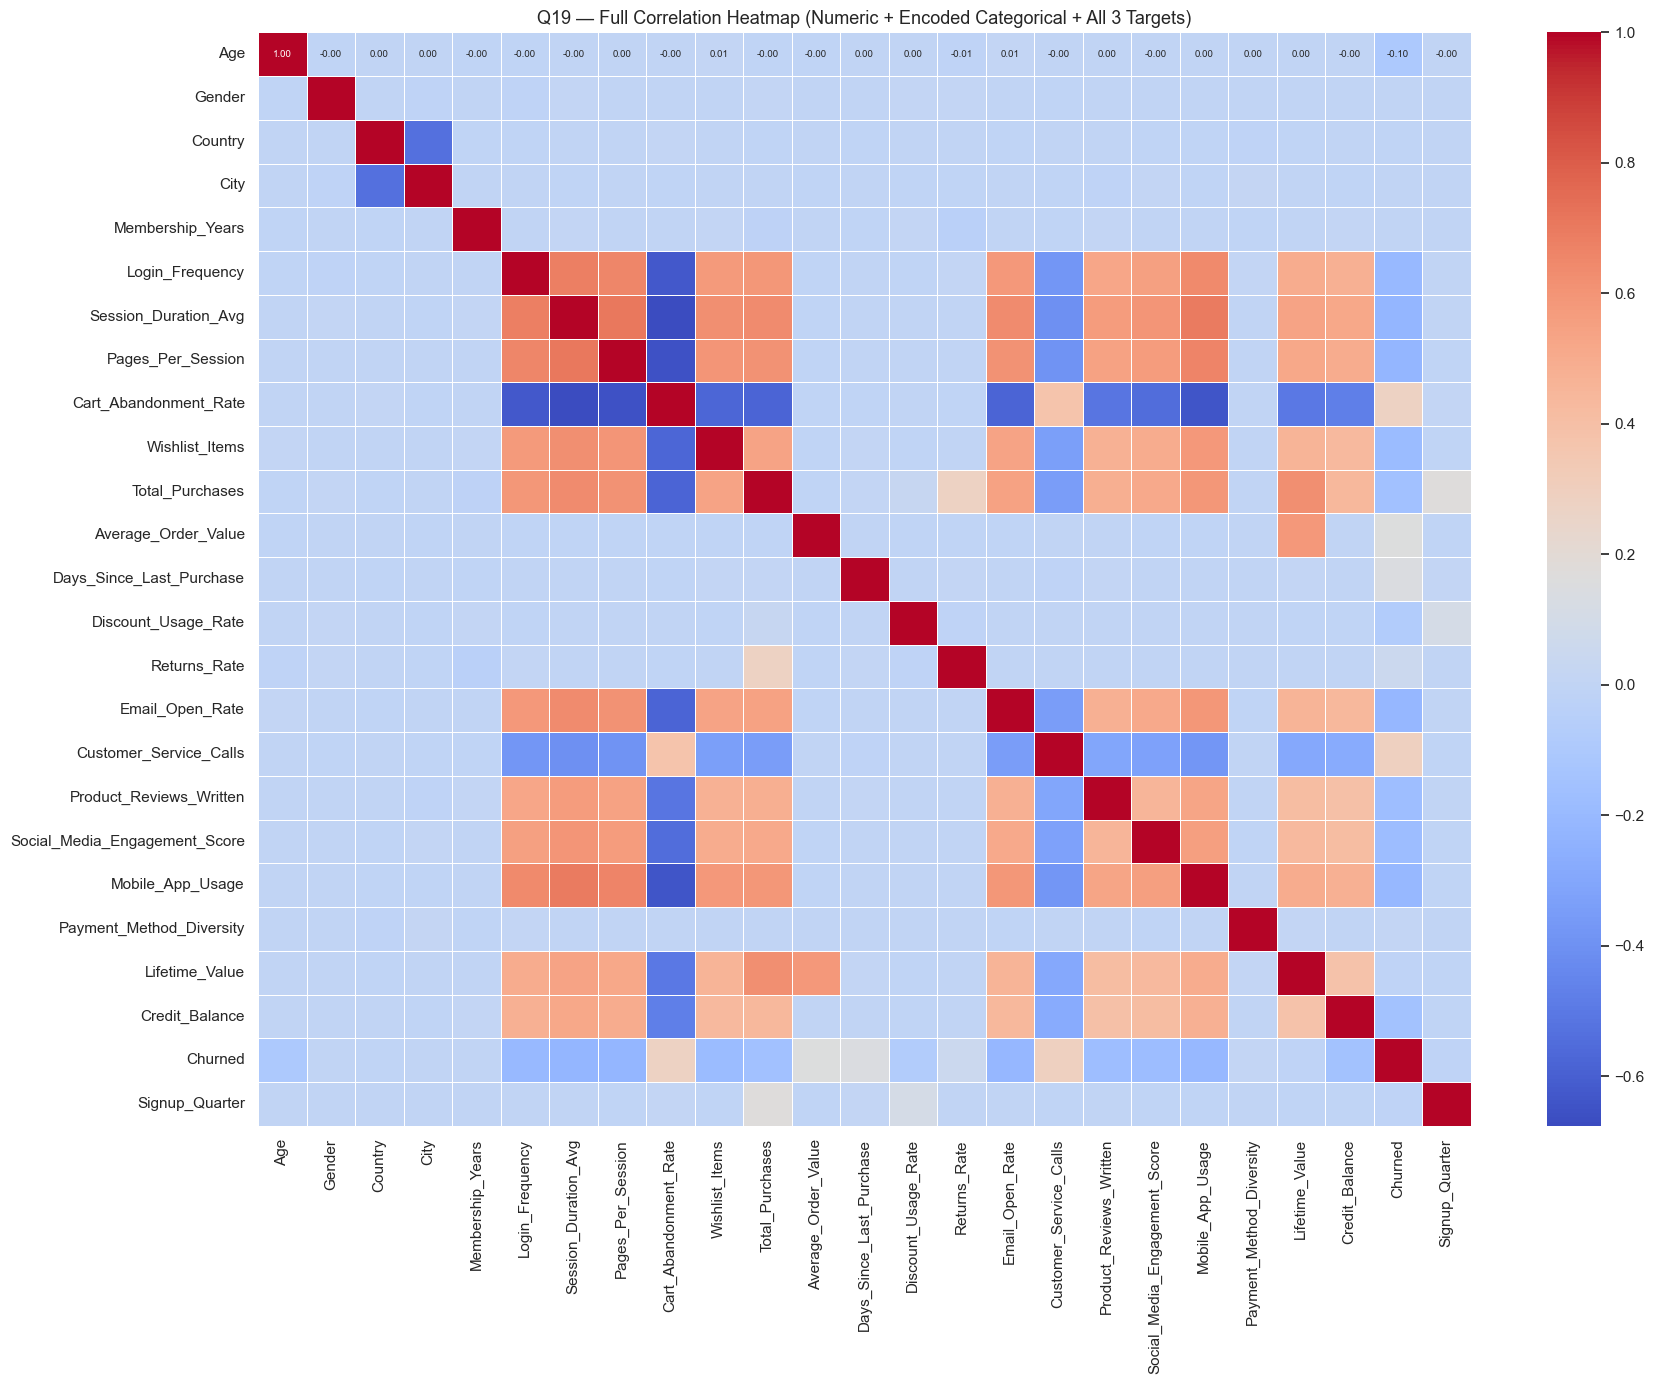

In [34]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-numeric ID columns and the Categorical target before encoding
drop_cols = ['CustomerID', 'LTV_Segment']
df_encoded = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Encode remaining categorical columns
le = LabelEncoder()
for col in cat_cols:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Add LTV_Segment back as ordinal integer
seg_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['LTV_Segment'] = df['LTV_Segment'].map(seg_map)

# Keep only numeric columns for correlation
df_encoded = df_encoded.select_dtypes(include='number')

full_corr = df_encoded.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Q19 — Full Correlation Heatmap (Numeric + Encoded Categorical + All 3 Targets)',
          fontsize=13)
plt.tight_layout()
plt.show()


### Top Features Correlated with Churned
| Feature | Correlation | Strength |
| :--- | :---: | :--- |
| Customer_Service_Calls | 0.289 | Moderate Positive |
| Cart_Abandonment_Rate | 0.278 | Moderate Positive |
| Pages_Per_Session | 0.223 | Positive |
| Session_Duration_Avg | 0.218 | Positive |
| Email_Open_Rate | 0.213 | Positive |
| Mobile_App_Usage | 0.210 | Positive |
| Login_Frequency | 0.203 | Positive |
| Wishlist_Items | 0.189 | Weak Positive |

---

### Top Features Correlated with Lifetime_Value
| Feature | Correlation | Strength |
| :--- | :---: | :--- |
| Total_Purchases | 0.625 | Strong Positive |
| Average_Order_Value | 0.586 | Strong Positive |
| Session_Duration_Avg | 0.541 | Strong Positive |
| Pages_Per_Session | 0.517 | Strong Positive |
| Mobile_App_Usage | 0.502 | Strong Positive |
| Login_Frequency | 0.501 | Strong Positive |
| Cart_Abandonment_Rate | 0.500 | Strong Positive |
| Email_Open_Rate | 0.460 | Moderate Positive |

---
**Q19 — Insight:** The full encoded correlation heatmap reveals three distinct clusters: (1) the user-activity block (Login_Frequency, Session_Duration_Avg, Pages_Per_Session), (2) the transaction block (Total_Purchases, Average_Order_Value, Lifetime_Value), and (3) the risk block (Cart_Abandonment_Rate, Customer_Service_Calls, Churned). Demographic encodings (Gender, Country, City) form an isolated block with near-zero correlation to all other features, confirming their limited predictive utility.

---
## Section E — Final Reporting

### Q20 — Final EDA Summary

## Final Summary & Data Transformation Plan

### Top 5 Insights
* **Churn Predictors:** Cart_Abandonment_Rate and Customer_Service_Calls are the strongest predictors of Churn — high values → high churn.
* **User Activity:** Active users (high Login_Frequency, long sessions, more pages) are significantly less likely to churn.
* **LTV & Engagement:** High LTV customers show higher engagement across all behavioral features — loyalty and spend are closely linked.
* **Demographic Impact:** Demographic features (Gender, Country, City, Signup_Quarter) show near-zero impact on both Churn and LTV.
* **Activity Clustering:** A strong user-activity cluster exists: Login_Frequency, Session_Duration_Avg, and Pages_Per_Session are highly inter-correlated (r > 0.65) — potential for dimensionality reduction.

---

### Top 5 Problems / Risks
1. **Missing Values:** 15 columns had missing values — handled via median/mean imputation.
2. **Feature Skewness:** 8 columns are right-skewed (skew > 0.9) — log transform needed before modeling.
3. **Data Quality:** Invalid values found: negative Total_Purchases, out-of-range rates, extreme AOV.
4. **Target Variance:** Lifetime_Value shows high variance — regression target will need log transform.
5. **Segment Validation:** LTV_Segment is engineered (not original) — segment boundaries depend on quantile cuts; business validation recommended.

---



---

### Next Steps
Apply log1p transformation to all right-skewed features, encode categorical columns (One-Hot for low-cardinality, Target Encoding for high-cardinality), then train baseline models: Logistic Regression and XGBoost for churn classification, Ridge Regression for Lifetime_Value prediction, and Multiclass Logistic for LTV_Segment. Evaluate with ROC-AUC for classification and RMSE for regression.


### Data Transformation Plan

**1. Handle Skewed Features — log1p transform:**
> Membership_Years, Wishlist_Items, Total_Purchases, Days_Since_Last_Purchase, Returns_Rate, Product_Reviews_Written, Payment_Method_Diversity, Average_Order_Value

**2. Encode Categorical Features:**
* **Gender, Signup_Quarter:** One-Hot Encoding (low cardinality).
* **Country, City:** Target Encoding or drop (high cardinality, low signal).

**3. Encode Targets:**
* **Churned:** Already binary (0/1).
* **LTV_Segment:** Ordinal encoding: Low=0, Medium=1, High=2.
* **Lifetime_Value:** Apply log1p (skewed regression target).

**4. Scaling:**
* **StandardScaler (Z-score):** For Logistic Regression / SVM / Neural Nets.
* **No Scaling:** For Tree-based models (XGBoost, Random Forest).

---

### Modeling Roadmap

| Target | Task | Recommended Models |
| :--- | :--- | :--- |
| **Churned** | Binary Classification | Logistic Regression, XGBoost, Random Forest |
| **Lifetime_Value** | Regression | Ridge, Gradient Boosting Regressor |
| **LTV_Segment** | Multiclass Classification | Multiclass Logistic, Random Forest |

**Final dataset shape ready for modeling: (44650, 26)**

In [33]:
# Save cleaned dataset
df.to_csv('ecommerce_cleaned_final.csv', index=False)
print('[OK] Cleaned dataset saved as ecommerce_cleaned_final.csv')

[OK] Cleaned dataset saved as ecommerce_cleaned_final.csv
